In [1]:
import numpy as np                                                                        
import matplotlib.pyplot as plt
import pyCloudy as pc
import pyneb as pn
from astropy    import constants as const
from astropy.io import ascii
import pandas as pd
from scipy import interpolate
import warnings
from scipy.integrate import quad, IntegrationWarning
import scipy.integrate as integrate
from numpy import log10, exp
import os
from astropy.constants import c
import astropy.units as u
from scipy import special
import matplotlib.gridspec as gridspec


from scipy.integrate import quad, IntegrationWarning
import scipy.integrate as integrate


from numpy import log10, exp
from DATA_CHECK import *

kpc = const.kpc.cgs.value

C_IV_K = 1548.187e-8  # cm
C_IV_H = 1550.772e-8  # cm

nu_Lya_K = c_cms / Ly_a_K
nu_Lya_H = c_cms / Ly_a_H

nu_CIV_K = c_cms / C_IV_K 
nu_CIV_H = c_cms / C_IV_H

Ryd_Lya_K = h_ev * nu_Lya_K / 13.6 
Ryd_Lya_H = h_ev * nu_Lya_H / 13.6 

Ryd_CIV_K = h_ev * nu_CIV_K / 13.6 
Ryd_CIV_H = h_ev * nu_CIV_H / 13.6 




n_H at 40 kpc = 2.56e-03
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Lya Luminosity = 4.95e+39 [erg/s]
C IV Luminosity = 1.30e+37 [erg/s]
HeII Luminosity = 7.23e+37 [erg/s]
----------------------------------------------------------------------------------------------------
Lya Column_density = 3.21e+20 [cm-2]
C IV Column_density = 1.74e+15 [cm-2]
He II Column_density = 6.62e+18 [cm-2]
----------------------------------------------------------------------------------------------------
U = -3.7445431950714614 [cm-2]
----------------------------------------------------------------------------------------------------
CIV / Lya = 0.0026  (0.16)
HeII / Lya = 0.015  (0.11)


Text(0, 0.5, '$\\rm SB(z) x (1+z)^4$ $\\rm [erg \\,s^{-1} \\, cm^{-2}]$ ')

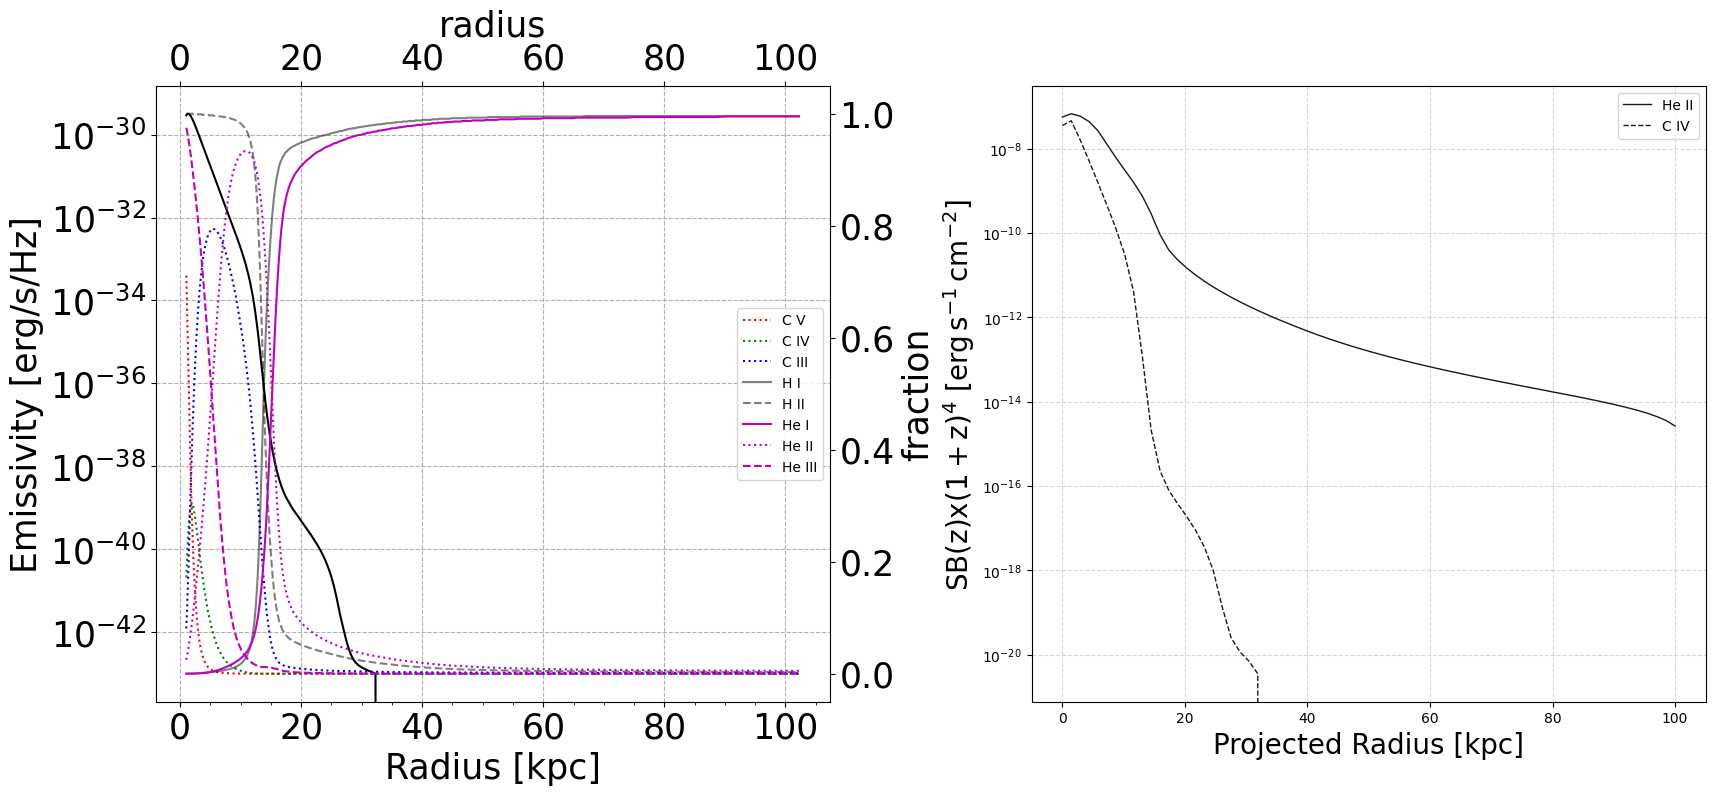

In [2]:
# Lumin =43.5 # 37.0 - 44.0 + 41.5, 42.5, 43.5 and 44.5
# idx_1 = 1 # 1 "" and  2 "no line transfer"
# idx_2 = 2
# metals = 0.01 # 0.001 - 10.0
# Column_density_order = 21.0  # 18.0 - 25.0
# cloudy_path_1 = CLOUDY_path(Lumin,idx_1,metals,Column_density_order)
# cloudy_path_2 = CLOUDY_path(Lumin,idx_2,metals,Column_density_order)

# print(cloudy_path_1)
# cloudy_1 = f"/home/jin/RT/Test_CLOUDY/number_den/hden_0500/Lum_{Lumin}_1/metal_{metals}/N_H_1.0_22.0/QSO_W"
# cloudy_2 = f"/home/jin/RT/Test_CLOUDY/number_den/hden_0500/Lum_{Lumin}_1/metal_{metals}/N_H_1.0_22.0/QSO_WO"
# cloudy_data_1 = CLOUDY_data_path(cloudy_1)
# cloudy_data_2 = CLOUDY_data_path(cloudy_2)

Lumin = 40.0 # 37.0 - 44.0 + 41.5, 42.5, 43.5 and 44.5
idx_1 = 1 # 1 "" and  2 "no line transfer"
idx_2 = 2
metals = 0.1 # 0.001 - 10.0
Column_density_order = 20.5  # 18.0 - 25.0
n_h_40 = (10**Column_density_order) / (40*kpc)
print(f"n_H at 40 kpc = {n_h_40:.2e}" )

cloudy_path_1 = CLOUDY_path(Lumin,idx_1,metals,Column_density_order)
cloudy_path_2 = CLOUDY_path(Lumin,idx_2,metals,Column_density_order)

cloudy_data_1 = CLOUDY_data_path(cloudy_path_1)
cloudy_data_2 = CLOUDY_data_path(cloudy_path_2)

print('--'*50)


print('--'*50)
print(f"Lya Luminosity = {cloudy_data_2[f'Lumin_Lya']:.2e} [erg/s]")
print(f"C IV Luminosity = {cloudy_data_2[f'Lumin_CIV']:.2e} [erg/s]")
print(f"HeII Luminosity = {cloudy_data_2[f'Lumin_HeII']:.2e} [erg/s]")
print('--'*50)
print(f"Lya Column_density = {cloudy_data_2[f'Column_density_H']:.2e} [cm-2]")
print(f"C IV Column_density = {cloudy_data_2[f'Column_density_CIV']:.2e} [cm-2]")
print(f"He II Column_density = {cloudy_data_2[f'Column_density_HeII']:.2e} [cm-2]")
print('--'*50)
print(f"U = {cloudy_data_2[f'logU'].mean()} [cm-2]")
print('--'*50)
f_civ_lya = cloudy_data_2[f'Lumin_CIV'] / cloudy_data_2[f'Lumin_Lya']
f_heii_lya = cloudy_data_2[f'Lumin_HeII'] / cloudy_data_2[f'Lumin_Lya']

print(f"CIV / Lya = {f_civ_lya:.2}  (0.16)")
print(f"HeII / Lya = {f_heii_lya:.2}  (0.11)")
fig = plt.figure(1, figsize=(20, 8))  # 세로로 조금 더 긴 그림
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.3)

# width_ratios=[2, 1]

ax1 = fig.add_subplot(gs[0])

atom = 'HeII'
# plt.plot(cloudy_data_1[f'radius_{Lumin}'],cloudy_data_1[f'emis_{atom}_{Lumin}'],'r-',label=f'{atom} with LT')
# plt.plot(cloudy_data_2[f'radius_{Lumin}_{2}'],cloudy_data_2[f'emis_{atom}_{Lumin}'],'r--',label=f'{atom} without LT')
atom = 'CIV'
# plt.plot(cloudy_data_1[f'radius'],cloudy_data_1[f'emis_{atom}'],'b-',label=f'{atom} with LT')
ax1.plot(cloudy_data_2[f'radius'],cloudy_data_2[f'emis_{atom}'],'k-',label=f'{atom} emissivity')

# ax1.axvline(x=12,ymin=0,ymax=1,lw=3,alpha=0.5,color='k')
# ax1.axvline(x=25,ymin=0,ymax=1,lw=3,alpha=0.5,color='k')

ax2 = fig.add_axes(ax1.get_position(), frameon=False)

ax2.plot(cloudy_data_2[f'radius'], cloudy_data_2[f'frac_CV'],'r:',label = 'C V')
ax2.plot(cloudy_data_2[f'radius'], cloudy_data_2[f'frac_CIV'],'g:',label = 'C IV')
ax2.plot(cloudy_data_2[f'radius'],cloudy_data_2[f'frac_CIII'],'b:',label = 'C III')


plt.plot(cloudy_data_2[f'radius'],cloudy_data_2[f'frac_HI'],'k-',alpha=0.5,label=f'H I')
plt.plot(cloudy_data_2[f'radius'],cloudy_data_2[f'frac_HII'],'k--',alpha=0.5,label=f'H II')

ax2.plot(cloudy_data_2[f'radius'], cloudy_data_2[f'frac_HeI'],'m-',label = 'He I')
ax2.plot(cloudy_data_2[f'radius'],cloudy_data_2[f'frac_HeII'],'m:',label = 'He II')
ax2.plot(cloudy_data_2[f'radius'],cloudy_data_2[f'frac_HeIII'],'m--',label = 'He III')

ax1.set_xlabel('Radius [kpc]',fontsize=25)
ax1.set_ylabel('Emissivity [erg/s/Hz]',fontsize=25)
ax1.tick_params(axis='both', labelsize=25)
# ax2.set_ylabel('fraction',fontsize=25)
ax1.set_yscale('log')

ax1.minorticks_on()
ax1.grid(True,linestyle='--')


ax2.xaxis.set_ticks_position('top')
ax2.xaxis.set_label_position('top')
ax2.set_xlabel('radius', fontsize=25)

ax2.yaxis.set_ticks_position('right')
ax2.yaxis.set_label_position('right')
ax2.set_ylabel('fraction', fontsize=25)
ax2.tick_params(axis='both', labelsize=25)

plt.legend()


ax3 = fig.add_subplot(gs[1])

radius_Te_W_LT, SB_Te_W_LT = cloudy_data_1[f'radius_p'] , cloudy_data_1[f'SB_{atom}']
radius_Te_WO_LT, SB_Te_WO_LT = cloudy_data_2[f'radius_p'] , cloudy_data_2[f'SB_{atom}']

radius_Te_WO_LT, SB_Te_WO_LT_HeII = cloudy_data_2[f'radius_p'] , cloudy_data_2[f'SB_HeII']

ax3.plot(radius_Te_WO_LT, SB_Te_WO_LT_HeII,'k-',lw=1,alpha=0.9,label='He II')
ax3.plot(radius_Te_WO_LT,SB_Te_WO_LT,'k--',lw=1,alpha=0.9,label='C IV')
# ax3.plot(radius_Te_W_LT,SB_Te_W_LT,'r--',lw=1,alpha=0.9,label='C IV')
# ax3.axvline(x=42,ymin=0,ymax=1)

ax3.set_yscale('log')

ax3.legend()

ax3.grid(True,linestyle='--',alpha=0.5)

ax3.set_xlabel('Projected Radius [kpc]', fontsize=20)
ax3.set_ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2}]$ ', fontsize=20)

# ax3.set_xlim(-0.1,2)
# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/L_45_5_NH_22_M_10', bbox_inches='tight')

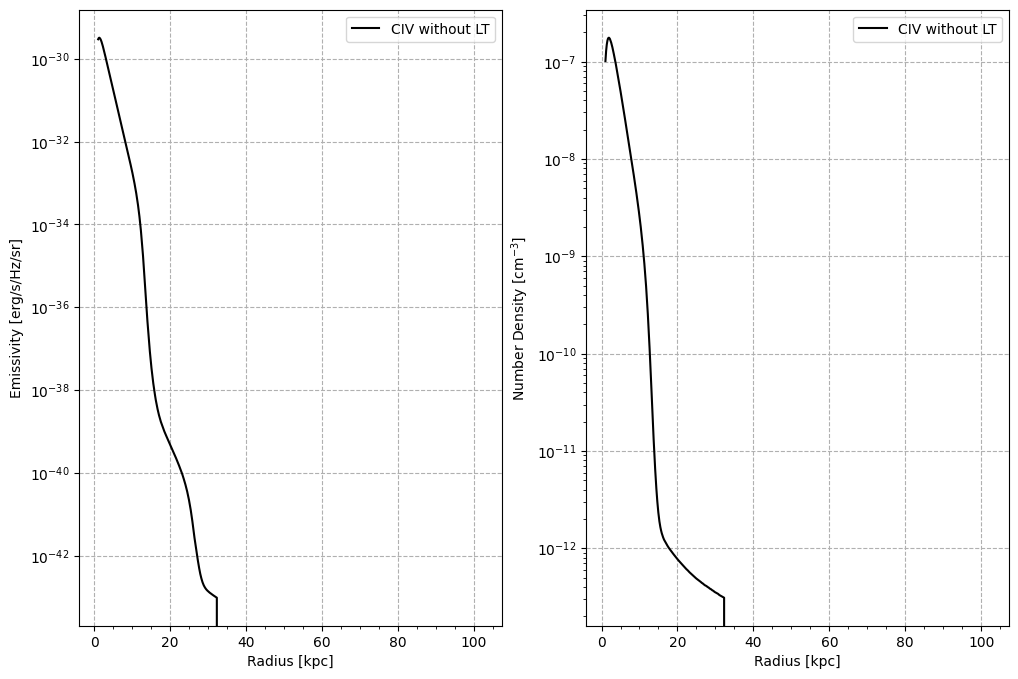

In [4]:

# Lumin =43.5 # 37.0 - 44.0 + 41.5, 42.5, 43.5 and 44.5
# idx_1 = 1 # 1 "" and  2 "no line transfer"
# idx_2 = 2
# metals = 0.1 # 0.001 - 10.0
# Column_density_order = 22.0  # 18.0 - 25.0
# cloudy_path_1 = CLOUDY_path(Lumin,idx_1,metals,Column_density_order)
# cloudy_path_2 = CLOUDY_path(Lumin,idx_2,metals,Column_density_order)

# print(cloudy_path_1)
# cloudy_1 = f"/home/jin/RT/Test_CLOUDY/number_den/hden_1/Lum_{Lumin}_1/metal_{metals}/N_H_1.0_22.0/QSO_W"
# cloudy_2 = f"/home/jin/RT/Test_CLOUDY/number_den/hden_1/Lum_{Lumin}_1/metal_{metals}/N_H_1.0_22.0/QSO_WO"
# cloudy_data_1 = CLOUDY_data_path(cloudy_1)
# cloudy_data_2 = CLOUDY_data_path(cloudy_2)

z = 0
red_shift_f = (1+z)**4
sr_to_arc = (180*3600 / np.pi)**2
fac = 1.0 #red_shift_f / sr_to_arc
fig= plt.figure(1,figsize=(12,8))
plt.subplot(1,2,1)


atom = 'HeII'
# plt.plot(cloudy_data_1[f'radius_{Lumin}'],cloudy_data_1[f'emis_{atom}_{Lumin}'],'r-',label=f'{atom} with LT')
# plt.plot(cloudy_data_2[f'radius_{Lumin}_{2}'],cloudy_data_2[f'emis_{atom}_{Lumin}'],'r--',label=f'{atom} without LT')
atom = 'CIV'
# plt.plot(cloudy_data_1[f'radius_{Lumin}'],cloudy_data_1[f'emis_{atom}_{Lumin}'],'b-',label=f'{atom} with LT')
plt.plot(cloudy_data_2[f'radius'],cloudy_data_2[f'emis_{atom}'],'k-',label=f'{atom} without LT')
# ax2.plot(cloudy_data_2[f'radius_{Lum}_{idx_2}'], cloudy_data_2[f'frac_CV_{Lum}_{idx_2}'],'r:',label = 'C V')
# ax2.plot(cloudy_data_2[f'radius_{Lum}_{idx_2}'], cloudy_data_2[f'frac_CIV_{Lum}_{idx_2}'],'g:',label = 'C IV')
# ax2.plot(cloudy_data_2[f'radius_{Lum}_{idx_2}'],cloudy_data_2[f'frac_CIII_{Lum}_{idx_2}'],'b:',label = 'C III')

plt.xlabel('Radius [kpc]')
plt.ylabel('Emissivity [erg/s/Hz/sr]')
plt.yscale('log')
plt.minorticks_on()
plt.grid(True,linestyle='--')

plt.legend()

plt.subplot(1,2,2)
# atom = 'HeII'
# plt.plot(cloudy_data_1[f'radius_{Lumin}'],cloudy_data_1[f'nden_{atom}_{Lumin}'],'r-',label=f'{atom} with LT')
# plt.plot(cloudy_data_2[f'radius_{Lumin}'],cloudy_data_2[f'nden_{atom}_{Lumin}'],'r--',label=f'{atom} without LT')
atom = 'CIV'
# plt.plot(cloudy_data_1[f'radius_{Lumin}'],cloudy_data_1[f'nden_{atom}_{Lumin}'],'b-',label=f'{atom} with LT')
plt.plot(cloudy_data_2[f'radius'],cloudy_data_2[f'nden_{atom}'],'k-',label=f'{atom} without LT')
plt.xlabel('Radius [kpc]')
plt.ylabel('Number Density [cm$^{-3}$]')
plt.yscale('log')

plt.minorticks_on()
plt.grid(True,linestyle='--')


plt.legend()


# print(f"HeI Luminosity = {cloudy_data_1[f'Lumin_HeI_{Lumin}_{idx}']:.4e} [erg/s]")

# f'Column_density_CIV_{Lumin}_{idx}'

# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/parameter', bbox_inches='tight')

In [5]:
n_H = cloudy_data_1["Column_density_H"]
print(n_H)

3.207858815730001e+20


In [6]:
n_H = (10**21)/(100*kpc)
# print(n_H)
# Lumin =45.5 # 37.0 - 44.0 + 41.5, 42.5, 43.5 and 44.5
# idx_1 = 1 # 1 "" and  2 "no line transfer"
# idx_2 = 2
# metals = 0.1 # 0.001 - 10.0
# Column_density_order = 22.0  # 18.0 - 25.0

# cloudy_path_1 = CLOUDY_path(Lumin,idx_1,metals,Column_density_order)
# cloudy_path_2 = CLOUDY_path(Lumin,idx_2,metals,Column_density_order)

# cloudy_data_1 = CLOUDY_data_path(cloudy_path_1)
# cloudy_data_2 = CLOUDY_data_path(cloudy_path_2)

# n_H = cloudy_data_1["nH"]
# print(n_H)

In [4]:
Lumin =45.5 # 37.0 - 44.0 + 41.5, 42.5, 43.5 and 44.5
idx_1 = 1 # 1 "" and  2 "no line transfer"
idx_2 = 2
metals = 0.1 # 0.001 - 10.0
Column_density_order = 22.0  # 18.0 - 25.0


cloudy_path_455 = CLOUDY_path(45.5,idx_2,metals,Column_density_order)
cloudy_path_435 = CLOUDY_path(43.5,idx_2,metals,Column_density_order)

cloudy_data_435 = CLOUDY_data_path(cloudy_path_435)
cloudy_data_455 = CLOUDY_data_path(cloudy_path_455)

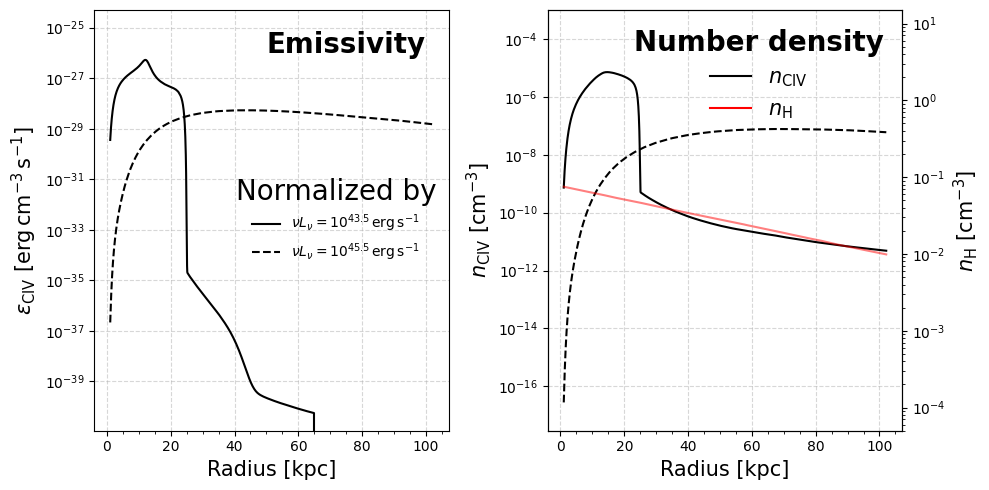

In [16]:
fig = plt.figure(1,figsize=(10,5))

ax= plt.subplot(121)
ax.plot(cloudy_data_435['radius'], cloudy_data_435[f'emis_{atom}'], 'k-',label=f'$\\nu L_{{\\nu}} = 10^{{43.5}} \\, \\rm{{erg}} \\, s^{{-1}}$')
ax.plot(cloudy_data_455['radius'], cloudy_data_455[f'emis_{atom}'], 'k--',label=f'$\\nu L_{{\\nu}} = 10^{{45.5}} \\, \\rm{{erg}} \\, s^{{-1}}$')

# ax.plot(cloudy_data_435['radius'], cloudy_data_435[f'emis_HeII'], 'r-',label=r"${\rm He II}$") # , label=f" $\\nu L_{{\\nu}} = 10^{{45.5}} \\, \\rm{{erg}} \\, s^{{-1}}$"
# ax.plot(cloudy_data_455['radius'], cloudy_data_455[f'emis_HeII'], 'r--') # , label=f" $\\nu L_{{\\nu}} = 10^{{45.5}} \\, \\rm{{erg}} \\, s^{{-1}}$"



ax.grid(True,linestyle='--',alpha=0.5)

ax.set_yscale('log')
# ax2.set_yscale('log')

ax.set_ylim(ymax=5e-25)
# ax.legend(loc='lower right', frameon=True)

# leg = ax.legend(
#     fontsize=10,
#     title=r'Ionic',
#     loc='upper right',
#     title_fontsize=10,
#     frameon=True
# )


leg = ax.legend(
    fontsize=10,
    title=r'Normalized by',
    loc='center right',
    title_fontsize=20,
    frameon=False
)

# leg = ax3.legend(
#     fontsize=10,
#     title=r'Normalized by',
#     loc='upper right',
#     title_fontsize=20,
#     frameon=True
# )




# leg.get_frame().set_facecolor('white')
# leg.get_frame().set_alpha(1)
# leg.get_frame().set_edgecolor('white') 

# ax.axvline(x=25,ymin=0,ymax=1,lw=3,alpha=0.5,color='gray',linestyle='--')


# ax.text(70, 3e-25/10, s=f'Emissivity', fontsize=15, fontweight='bold')

ax.text(50,1e-26,s='Emissivity',size=20,fontweight='bold')

ax.set_xlabel('Radius [kpc]',fontsize=15)
ax.set_ylabel(
    r'$\epsilon_{\rm CIV}\ \mathrm{[erg\,cm^{-3}\,s^{-1}]}$',
    fontsize=15
)


# ax.set_ylabel(r'$\epsilon_{\rm C\,IV}\ \mathrm{[erg\,cm^{-3}\,s^{-1}]}$',fontsize=15)
# ax.set_ylabel(
#     r'$\epsilon_{\rm C\,IV}\ \mathrm{[erg\,cm^{-3}\,s^{-1}]}$',
#     fontsize=15
# ) 
ax.minorticks_on()


# ax2 = ax.twinx()

# ax2.plot(cloudy_data_435['radius'], cloudy_data_435[f'Te'], 'r:', label=f" $\\nu L_{{\\nu}} = 10^{{45.5}} \\, \\rm{{erg}} \\, s^{{-1}}$")
# ax2.set_ylabel(r'$ \rm T_{\rm e}$')
# plt.axvline(x=12,ymin=0,ymax=1,lw=3,alpha=0.2,color='y')
# plt.axvline(x=25,ymin=0,ymax=1,lw=3,alpha=0.2,color='m')


ax3 = plt.subplot(122)
# 이거 아닌가
# ax3.plot(cloudy_data_435['radius'], cloudy_data_435[f'nden_{atom}'], 'k-') # , label=f"$n_{{\\rm C\\ IV}}$ at $\\nu L_{{\\nu}} = 10^{{43.5}}$"
# ax3.plot(cloudy_data_455['radius'], cloudy_data_455[f'nden_{atom}'], 'k--') # , label=f"$n_{{\\rm C\\ IV}}$ (Fully ionized H I)"

ax3.plot(cloudy_data_435['radius'], cloudy_data_435[f'nden_{atom}'], 'k-',label=r'$n_{\rm CIV}$')
ax3.plot(cloudy_data_455['radius'], cloudy_data_455[f'nden_{atom}'], 'k--') # , label=f" $\\nu L_{{\\nu}} = 10^{{45.5}} \\, \\rm{{erg}} \\, s^{{-1}}$"

ax3.axhline(y=1000,xmin=0,xmax=1,linestyle='-',color='r',label=r'$n_{\rm H}$')

ax4 = ax3.twinx()
ax4.plot(cloudy_data_435['radius'], cloudy_data_435[f'nH'], 'r-',alpha=0.5)

# ax3.plot(cloudy_data_435['radius'], cloudy_data_435[f'nden_HeII'], 'r-') # , label=f" $\\nu L_{{\\nu}} = 10^{{45.5}} \\, \\rm{{erg}} \\, s^{{-1}}$"
# ax3.plot(cloudy_data_455['radius'], cloudy_data_455[f'nden_HeII'], 'r--') # , label=f" $\\nu L_{{\\nu}} = 10^{{45.5}} \\, \\rm{{erg}} \\, s^{{-1}}$"


leg = ax3.legend(
    fontsize=15,
    title=r'Number density',
    title_fontproperties={'weight': 'bold', 'size': 20},
    loc='upper right',
    frameon=False
)

# leg.get_frame().set_facecolor('white')
# leg.get_frame().set_alpha(1)
# leg.get_frame().set_edgecolor('white') 


ax3.grid(True,linestyle='--',alpha=0.5)

ax3.set_yscale('log')


# ax3.text(50, 1e-4/10, s=f'Number density', fontsize=15, fontweight='bold')


ax3.set_xlabel('Radius [kpc]',fontsize=15)
ax3.set_ylabel(r'$n_{\mathrm{CIV}}\ \mathrm{[cm^{-3}]}$', fontsize=15)
ax4.set_ylabel(r'$n_{\mathrm{H}}\ \mathrm{[cm^{-3}]}$', fontsize=15)

ax4.set_ylim(ymax=1,ymin=0.005)

# ax4.set_ylabel(r'$n_{\rm H}$ $ \rm [ cm^{-3}]$',fontsize=15)
# ax4.tick_params(axis='y', labelcolor='k', labelsize=10)
# 이거 맞아?
ax4.tick_params(axis='y', labelcolor='k', labelsize=10)
ax4.set_yticks([0.00005,0.001, 0.01, 0.1, 1.0,15.0])
ax4.set_yticklabels([str(tick) for tick in [0.0001,0.001, 0.01, 0.1, 1.0,10.0]])


ax4.set_yscale('log')


ax3.tick_params(axis='y', labelcolor='k', labelsize=10)
ax3.tick_params(axis='x', labelcolor='k', labelsize=10)
ax3.minorticks_on()


ax3.set_ylim(ymax=1e-3)
plt.tight_layout()

# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Emis_Nden', bbox_inches='tight')

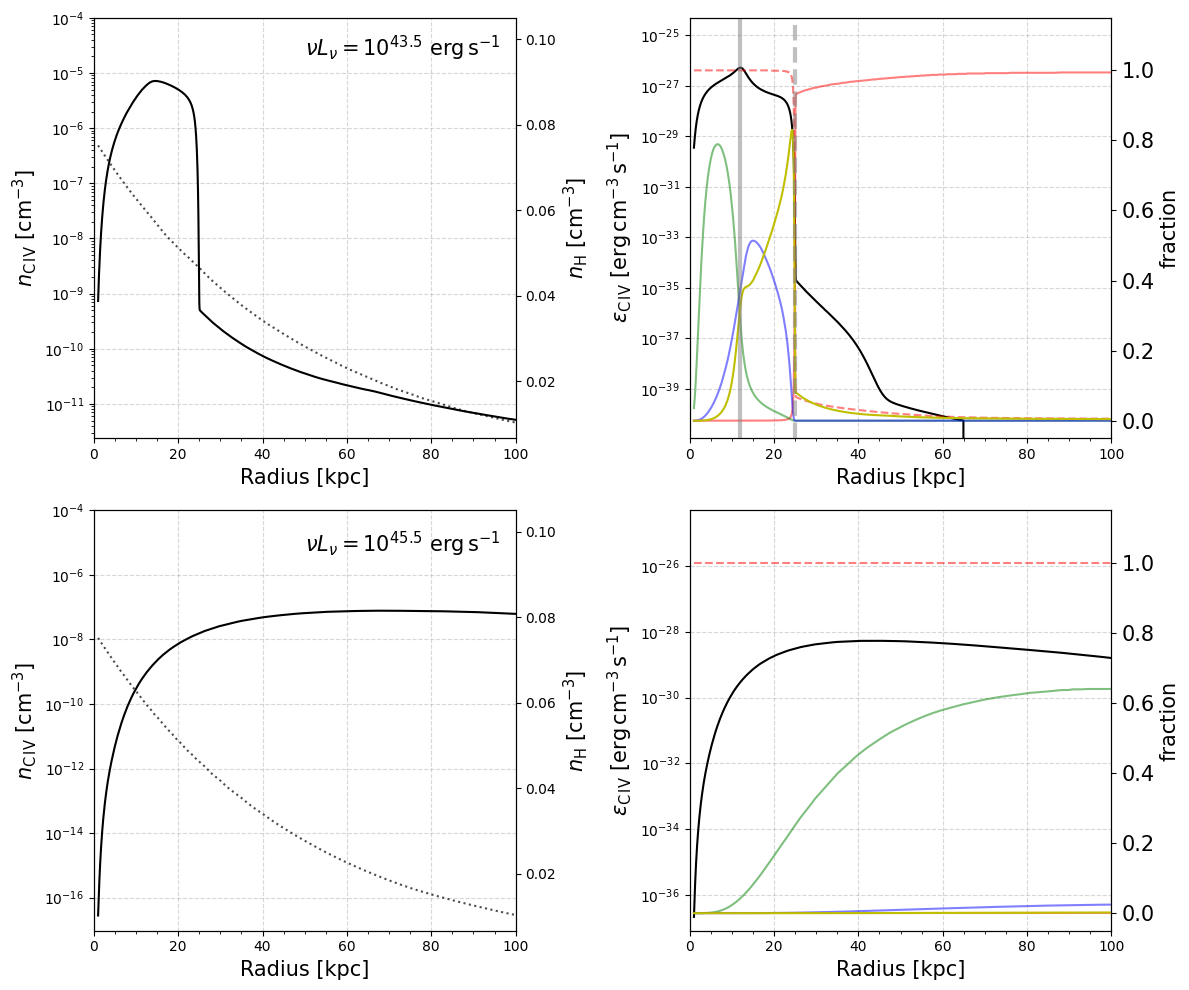

In [9]:
fig = plt.figure(figsize=(12,10))

# =========================
# Right panel: Emissivity
# =========================
ax = plt.subplot(222)

ax.plot(
    cloudy_data_435['radius'],
    cloudy_data_435[f'emis_{atom}'],
    'k-',
    # label='Partially ionized H I'
)


ax.grid(True, linestyle='--', alpha=0.5)
ax.set_yscale('log')
ax.set_ylim(ymax=5e-25)

ax.set_xlabel('Radius [kpc]', fontsize=15)
ax.set_xlim(0,100)

ax.set_ylabel(
    r'$\epsilon_{\rm C\,IV}\ \mathrm{[erg\,cm^{-3}\,s^{-1}]}$',
    fontsize=15
)
ax.minorticks_on()

ax2 = ax.twinx()
ax2.plot(cloudy_data_435[f'radius'], cloudy_data_435[f'frac_HI'],'r-',alpha=0.5,label = 'C V')
ax2.plot(cloudy_data_435[f'radius'], cloudy_data_435[f'frac_HII'],'r--',alpha=0.5,label = 'C IV')

ax2.plot(cloudy_data_435[f'radius'], cloudy_data_435[f'frac_CV'],'g-',alpha=0.5,label = 'C V')
ax2.plot(cloudy_data_435[f'radius'], cloudy_data_435[f'frac_CIV'],'b-',alpha=0.5,label = 'C IV')
ax2.plot(cloudy_data_435[f'radius'],cloudy_data_435[f'frac_CIII'],'y-',label = 'C III')



ax2.axvline(x=12,ymin=0,ymax=1,lw=3,alpha=0.5,color='gray',linestyle='-')
ax2.axvline(x=25,ymin=0,ymax=1,lw=3,alpha=0.5,color='gray',linestyle='--')


# ax3.set_xlabel('Radius [kpc]',fontsize=15)
# ax3.tick_params(axis='both', labelsize=15)
# ax2.set_ylabel('fraction',fontsize=25)
# ax3.minorticks_on()
# ax3.grid(True,linestyle='--')

ax2.set_ylabel('fraction', fontsize=15)
ax2.tick_params(axis='both', labelsize=15)
ax2.set_ylim(ymax=1.15)



# ax.legend(title='Emissivity',frameon=False,title_fontsize=15)

# =========================
# Left panel: Number density
# =========================
ax3 = plt.subplot(221)

ax3.text(50,2e-5, r'$\nu L_{\nu} = 10^{43.5}\ \mathrm{erg\,s^{-1}}$',fontsize=15, fontweight='bold')

# C IV number density
ax3.plot(
    cloudy_data_435['radius'],
    cloudy_data_435[f'nden_{atom}'],
    'k-'
)

ax3.set_yscale('log')
ax3.set_ylim(ymax=1e-4)

ax3.set_xlabel('Radius [kpc]', fontsize=15)
ax3.set_xlim(0,100)

ax3.set_ylabel(
    r'$n_{\rm C\,IV}\ \mathrm{[cm^{-3}]}$',
    fontsize=15
)

ax3.grid(True, linestyle='--', alpha=0.5)
ax3.minorticks_on()

# =========================
# Secondary y-axis: Hydrogen density
# =========================
ax4 = ax3.twinx()

ax4.plot(
    cloudy_data_435['radius'],
    cloudy_data_435['nH'],
    'k:',
    # label='Hydrogen',
    alpha=0.7
)

ax4.set_ylabel(
    r'$n_{\rm H}\ \mathrm{[cm^{-3}]}$',
    fontsize=15
)
ax4.set_ylim(ymax=0.105)

# =========================
# Unified legend (left panel: Hydrogen only)
# =========================
handles4, labels4 = ax4.get_legend_handles_labels()

# ax3.legend(
#     handles4,
#     labels4,
#     title='Number density',
#     title_fontsize=15,
#     frameon=False,
#     loc='upper right'
# )

# ax3 = plt.subplot(131)




ax = plt.subplot(224)

ax.plot(
    cloudy_data_455['radius'],
    cloudy_data_455[f'emis_{atom}'],
    'k-',
    # label='Fully ionized H I'
)

ax.grid(True, linestyle='--', alpha=0.5)
ax.set_yscale('log')
ax.set_ylim(ymax=5e-25)
ax.set_xlim(0,100)

ax.set_xlabel('Radius [kpc]', fontsize=15)
ax.set_ylabel(
    r'$\epsilon_{\rm C\,IV}\ \mathrm{[erg\,cm^{-3}\,s^{-1}]}$',
    fontsize=15
)
ax.minorticks_on()

ax2 = ax.twinx()
ax2.plot(cloudy_data_455[f'radius'], cloudy_data_455[f'frac_HI'],'r-',alpha=0.5,label = 'C V')
ax2.plot(cloudy_data_455[f'radius'], cloudy_data_455[f'frac_HII'],'r--',alpha=0.5,label = 'C IV')

ax2.plot(cloudy_data_455[f'radius'], cloudy_data_455[f'frac_CV'],'g-',alpha=0.5,label = 'C V')
ax2.plot(cloudy_data_455[f'radius'], cloudy_data_455[f'frac_CIV'],'b-',alpha=0.5,label = 'C IV')
ax2.plot(cloudy_data_455[f'radius'],cloudy_data_455[f'frac_CIII'],'y-',label = 'C III')

# ax3.set_xlabel('Radius [kpc]',fontsize=15)
# ax3.tick_params(axis='both', labelsize=15)
# ax2.set_ylabel('fraction',fontsize=25)
# ax3.minorticks_on()
# ax3.grid(True,linestyle='--')

ax2.set_ylabel('fraction', fontsize=15)
ax2.set_ylim(ymax=1.15)
ax2.tick_params(axis='both', labelsize=15)




# ax.legend(title='Emissivity',frameon=False,title_fontsize=15)

# =========================
# Left panel: Number density
# =========================
ax3 = plt.subplot(223)

# C IV number density
ax3.text(50,0.5e-5, r'$\nu L_{\nu} = 10^{45.5}\ \mathrm{erg\,s^{-1}}$',fontsize=15, fontweight='bold')

ax3.plot(
    cloudy_data_455['radius'],
    cloudy_data_455[f'nden_{atom}'],
    'k-'
)

ax3.set_yscale('log')
ax3.set_ylim(ymax=1e-4)

ax3.set_xlabel('Radius [kpc]', fontsize=15)
ax3.set_xlim(0,100)
ax3.set_ylabel(
    r'$n_{\rm C\,IV}\ \mathrm{[cm^{-3}]}$',
    fontsize=15
)

ax3.grid(True, linestyle='--', alpha=0.5)
ax3.minorticks_on()

# =========================
# Secondary y-axis: Hydrogen density
# =========================
ax4 = ax3.twinx()

ax4.plot(
    cloudy_data_455['radius'],
    cloudy_data_455['nH'],
    'k:',
    # label='Hydrogen',
    alpha=0.7
)

ax4.set_ylabel(
    r'$n_{\rm H}\ \mathrm{[cm^{-3}]}$',
    fontsize=15
)
ax4.set_ylim(ymax=0.105)

# =========================
# Unified legend (left panel: Hydrogen only)
# =========================
handles4, labels4 = ax4.get_legend_handles_labels()

# ax3.legend(
#     handles4,
#     labels4,
#     title='Number density',
#     title_fontsize=15,
#     frameon=False,
#     loc='upper right'
# )

# ax3 = plt.subplot(131)




plt.tight_layout()


# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Emis_Nden', bbox_inches='tight')


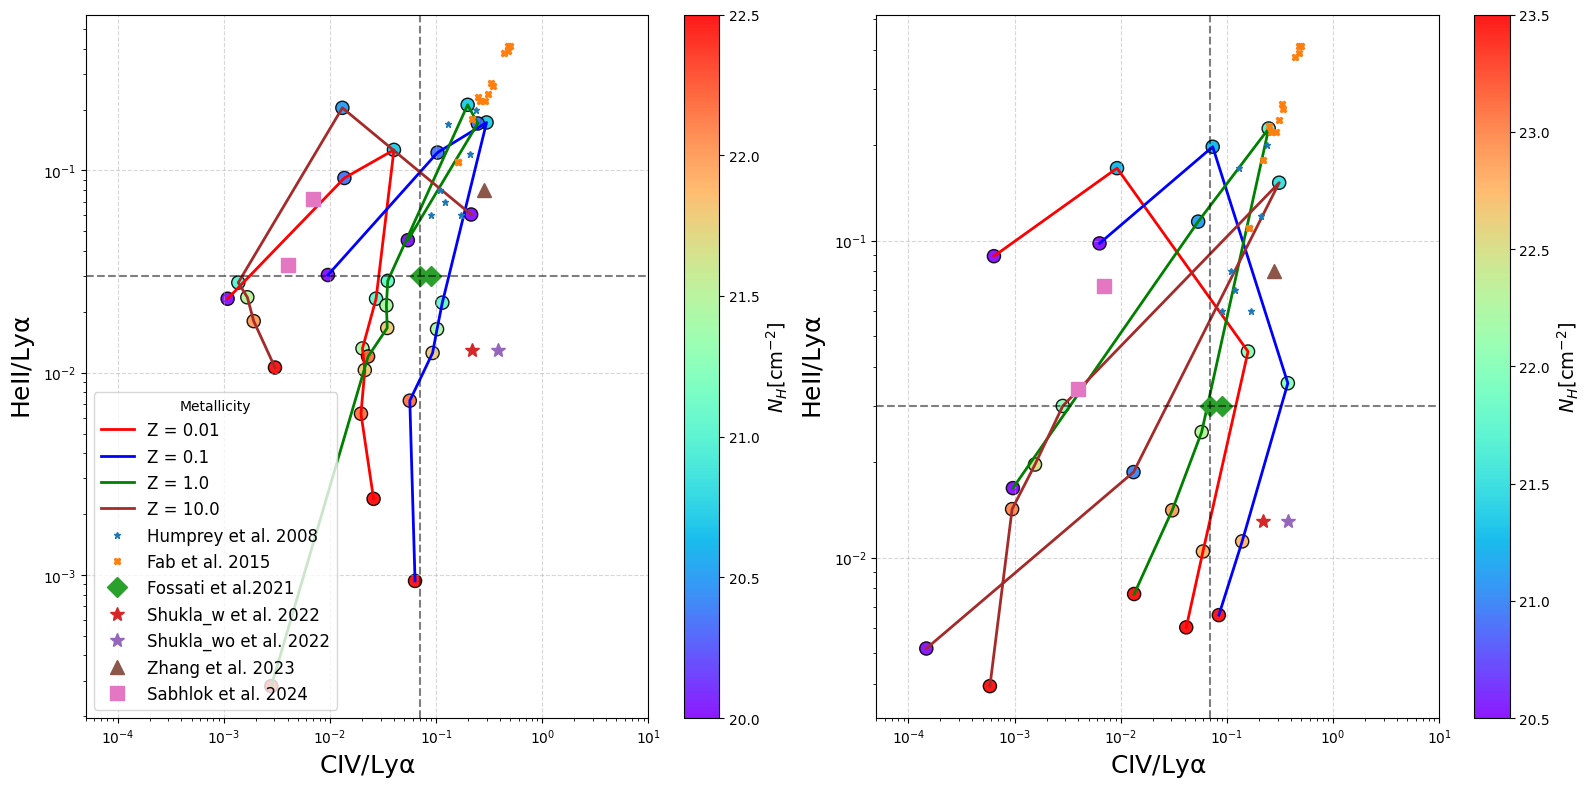

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 기본 파라미터

fig = plt.figure(1,figsize=(16,8))

plt.subplot(121)
Lumin = 43.5

idx_2 = 2

# metallicity 리스트 (트랙별 색상)
metals_list = [0.01,0.1,1.0,10.0]
colors = ['red', 'blue', 'green','brown','black']

# Column density range
N_list = np.arange(20.0, 24.0, 0.5)

# 1 kpc = 3.086e21 cm
kpc = 3.086e21
L_100kpc = 100 * kpc  # 100 kpc in cm

Hum_CIV = np.array([0.13,0.21,0.11,0.17,0.12,0.09,0.24])
Hum_HeII = np.array([0.17,0.12,0.08,0.06,0.07,0.06,0.20])

Fab_CIV = np.array([0.16,0.16,0.33,0.29,0.44,0.48,0.31,0.34,0.48,0.5,0.25,0.22,0.26])
Fab_HeII = np.array([0.11,0.11,0.27,0.22,0.38,0.39,0.24,0.26,0.41,0.41,0.23,0.18,0.22])

Fossat_CIV = np.array([0.07,0.09])
Fossat_HeII = np.array([0.03,0.03])

Zhang_CIV = np.array([0.28])
Zhang_HeII = np.array([0.08])


Sabhlokc_CIV = np.array([0.004,0.007])
Sabhlokc_HeII = np.array([0.034,0.072])

Shukla_CIV_w  = np.array([0.22])
Shukla_HeII_w  = np.array([0.066])

Shukla_CIV_wo  = np.array([0.38])
Shukla_HeII_wo  = np.array([0.013])

for Z, color in zip(metals_list, colors):

    civ_vals = []
    heii_vals = []
    cmap_vals = []      # log10(n_H_eff)
    nh_eff_vals = []    # 실제 n_H_eff 값 저장
    col_den_vals = []   # log10(N_H) 저장용
    for Column_density_order in N_list:

        cloudy_path = CLOUDY_path(Lumin, idx_2, Z, Column_density_order)
        cloudy_data = CLOUDY_data_path(cloudy_path)

        # Line luminosities
        L_civ = cloudy_data['Lumin_CIV']
        L_heii = cloudy_data['Lumin_HeII']
        L_lya = cloudy_data['Lumin_Lya']

        # Line ratios
        f_civ = L_civ / L_lya
        f_heii = L_heii / L_lya

        civ_vals.append(f_civ)
        heii_vals.append(f_heii)

        # n_H_eff 계산
        N_H = 10**Column_density_order    # cm^-2
        n_H_eff = N_H / L_100kpc          # cm^-3

        nh_eff_vals.append(n_H_eff)
        cmap_vals.append(np.log10(n_H_eff))
        col_den_vals.append(Column_density_order)
    # numpy array 변환
    civ_vals     = np.array(civ_vals)
    heii_vals    = np.array(heii_vals)
    cmap_vals    = np.array(cmap_vals)
    nh_eff_vals  = np.array(nh_eff_vals)
    col_den_vals = np.array(col_den_vals)

    

    # ======= ★ 필터링: x > 1e-4 조건 적용 =======
    mask = civ_vals > 1e-4
    civ_vals    = civ_vals[mask]
    heii_vals   = heii_vals[mask]
    cmap_vals   = cmap_vals[mask]
    nh_eff_vals = nh_eff_vals[mask]
    col_den_vals = col_den_vals[mask]
    # scatter plot
    sc = plt.scatter(civ_vals, heii_vals, c=col_den_vals,
                     cmap='rainbow', s=90, edgecolor='k', alpha=0.9)

    # metallicity track
    plt.plot(civ_vals, heii_vals, '-', lw=2,alpha=1.0,color=color, label=f"Z = {Z}")

    # 텍스트 레이블
    for x, y, logNH in zip(civ_vals, heii_vals, col_den_vals):
        label = rf"$10^{{{logNH:.1f}}}$"
        # plt.text(x*1.05, y*1.05, label,
        #         fontsize=9, ha='left', va='bottom')

# Colorbar
cb = plt.colorbar(sc)
cb.set_label(r'$N_H [{\rm cm^{-2}}]$', fontsize=14)

# Axes 설정
plt.xlabel(r'${\rm CIV} / {\rm Ly\alpha}$', fontsize=18)
plt.ylabel(r'${\rm HeII} / {\rm Ly\alpha}$', fontsize=18)

plt.xscale('log')
plt.yscale('log')

plt.xlim(5e-5, 10)
# plt.ylim(0.05, 1.2)

plt.plot(Hum_CIV, Hum_HeII, '*', markersize=5, label='Humprey et al. 2008')
plt.plot(Fab_CIV, Fab_HeII, 'X', markersize=5, label='Fab et al. 2015')

plt.plot(Fossat_CIV, Fossat_HeII, 'D', markersize=10, label='Fossati et al.2021')
plt.plot(Shukla_CIV_w, Shukla_HeII_wo, '*', markersize=10, label='Shukla_w et al. 2022')
plt.plot(Shukla_CIV_wo, Shukla_HeII_wo, '*', markersize=10, label='Shukla_wo et al. 2022')

plt.plot(Zhang_CIV, Zhang_HeII, '^', markersize=10, label='Zhang et al. 2023')
plt.plot(Sabhlokc_CIV, Sabhlokc_HeII, 's', markersize=10, label='Sabhlok et al. 2024')


# plt.axvline(x=0.16,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5)
# plt.axhline(y=0.11,xmin=0,xmax=1,linestyle='--',color='k',alpha=0.5)

plt.axvline(x=0.07,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5)
plt.axhline(y=0.03,xmin=0,xmax=1,linestyle='--',color='k',alpha=0.5)

plt.legend(title="Metallicity", fontsize=12)
plt.grid(True, ls='--', alpha=0.5)

plt.tight_layout()


# 기본 파라미터


plt.subplot(122)
Lumin = 45.5

idx_2 = 2

# metallicity 리스트 (트랙별 색상)
metals_list = [0.01,0.1,1.0,10.0]
colors = ['red', 'blue', 'green','brown','black']

# Column density range
N_list = np.arange(20.0, 24.0, 0.5)

# 1 kpc = 3.086e21 cm
kpc = 3.086e21
L_100kpc = 100 * kpc  # 100 kpc in cm

Hum_CIV = np.array([0.13,0.21,0.11,0.17,0.12,0.09,0.24])
Hum_HeII = np.array([0.17,0.12,0.08,0.06,0.07,0.06,0.20])

Fab_CIV = np.array([0.16,0.16,0.33,0.29,0.44,0.48,0.31,0.34,0.48,0.5,0.25,0.22,0.26])
Fab_HeII = np.array([0.11,0.11,0.27,0.22,0.38,0.39,0.24,0.26,0.41,0.41,0.23,0.18,0.22])

Fossat_CIV = np.array([0.07,0.09])
Fossat_HeII = np.array([0.03,0.03])

Zhang_CIV = np.array([0.28])
Zhang_HeII = np.array([0.08])


for Z, color in zip(metals_list, colors):

    civ_vals = []
    heii_vals = []
    cmap_vals = []      # log10(n_H_eff)
    nh_eff_vals = []    # 실제 n_H_eff 값 저장
    col_den_vals = []   # log10(N_H) 저장용
    for Column_density_order in N_list:

        cloudy_path = CLOUDY_path(Lumin, idx_2, Z, Column_density_order)
        cloudy_data = CLOUDY_data_path(cloudy_path)

        # Line luminosities
        L_civ = cloudy_data['Lumin_CIV']
        L_heii = cloudy_data['Lumin_HeII']
        L_lya = cloudy_data['Lumin_Lya']

        # Line ratios
        f_civ = L_civ / L_lya
        f_heii = L_heii / L_lya

        civ_vals.append(f_civ)
        heii_vals.append(f_heii)

        # n_H_eff 계산
        N_H = 10**Column_density_order    # cm^-2
        n_H_eff = N_H / L_100kpc          # cm^-3

        nh_eff_vals.append(n_H_eff)
        cmap_vals.append(np.log10(n_H_eff))
        col_den_vals.append(Column_density_order)
    # numpy array 변환
    civ_vals     = np.array(civ_vals)
    heii_vals    = np.array(heii_vals)
    cmap_vals    = np.array(cmap_vals)
    nh_eff_vals  = np.array(nh_eff_vals)
    col_den_vals = np.array(col_den_vals)

    

    # ======= ★ 필터링: x > 1e-4 조건 적용 =======
    mask = civ_vals > 1e-4
    civ_vals    = civ_vals[mask]
    heii_vals   = heii_vals[mask]
    cmap_vals   = cmap_vals[mask]
    nh_eff_vals = nh_eff_vals[mask]
    col_den_vals = col_den_vals[mask]
    # scatter plot
    sc = plt.scatter(civ_vals, heii_vals, c=col_den_vals,
                     cmap='rainbow', s=90, edgecolor='k', alpha=0.9)

    # metallicity track
    plt.plot(civ_vals, heii_vals, '-', lw=2, alpha=1.0,color=color, label=f"Z = {Z}")

    # 텍스트 레이블
    for x, y, logNH in zip(civ_vals, heii_vals, col_den_vals):
        label = rf"$10^{{{logNH:.1f}}}$"
        # plt.text(x*1.05, y*1.05, label,
        #         fontsize=9, ha='left', va='bottom')

# Colorbar
cb = plt.colorbar(sc)
cb.set_label(r'$N_H [{\rm cm^{-2}}]$', fontsize=14)

# Axes 설정
plt.xlabel(r'${\rm CIV} / {\rm Ly\alpha}$', fontsize=18)
plt.ylabel(r'${\rm HeII} / {\rm Ly\alpha}$', fontsize=18)

plt.xscale('log')
plt.yscale('log')

plt.xlim(5e-5, 10)
# plt.ylim(0.05, 1.2)

plt.plot(Hum_CIV, Hum_HeII, '*', markersize=5, label='Humprey et al. 2008')
plt.plot(Fab_CIV, Fab_HeII, 'X', markersize=5, label='Fab et al. 2015')
plt.plot(Fossat_CIV, Fossat_HeII, 'D', markersize=10, label='Fossati et al.2021')
plt.plot(Shukla_CIV_w, Shukla_HeII_wo, '*', markersize=10, label='Shukla_w et al. 2022')
plt.plot(Shukla_CIV_wo, Shukla_HeII_wo, '*', markersize=10, label='Shukla_wo et al. 2022')

plt.plot(Zhang_CIV, Zhang_HeII, '^', markersize=10, label='Zhang et al. 2023')
plt.plot(Sabhlokc_CIV, Sabhlokc_HeII, 's', markersize=10, label='Sabhlok et al. 2024')




# plt.axvline(x=0.16,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5)
# plt.axhline(y=0.11,xmin=0,xmax=1,linestyle='--',color='k',alpha=0.5)

plt.axvline(x=0.07,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5)
plt.axhline(y=0.03,xmin=0,xmax=1,linestyle='--',color='k',alpha=0.5)

# plt.legend(title="Metallicity", fontsize=12)
plt.grid(True, ls='--', alpha=0.5)

plt.tight_layout()





# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Line_ratio', bbox_inches='tight')
# 
# 이거 지금 color 가 nh_eff_Vals 로 들어가는데 그냥 label 에는 column density 로 들어가게 가능?

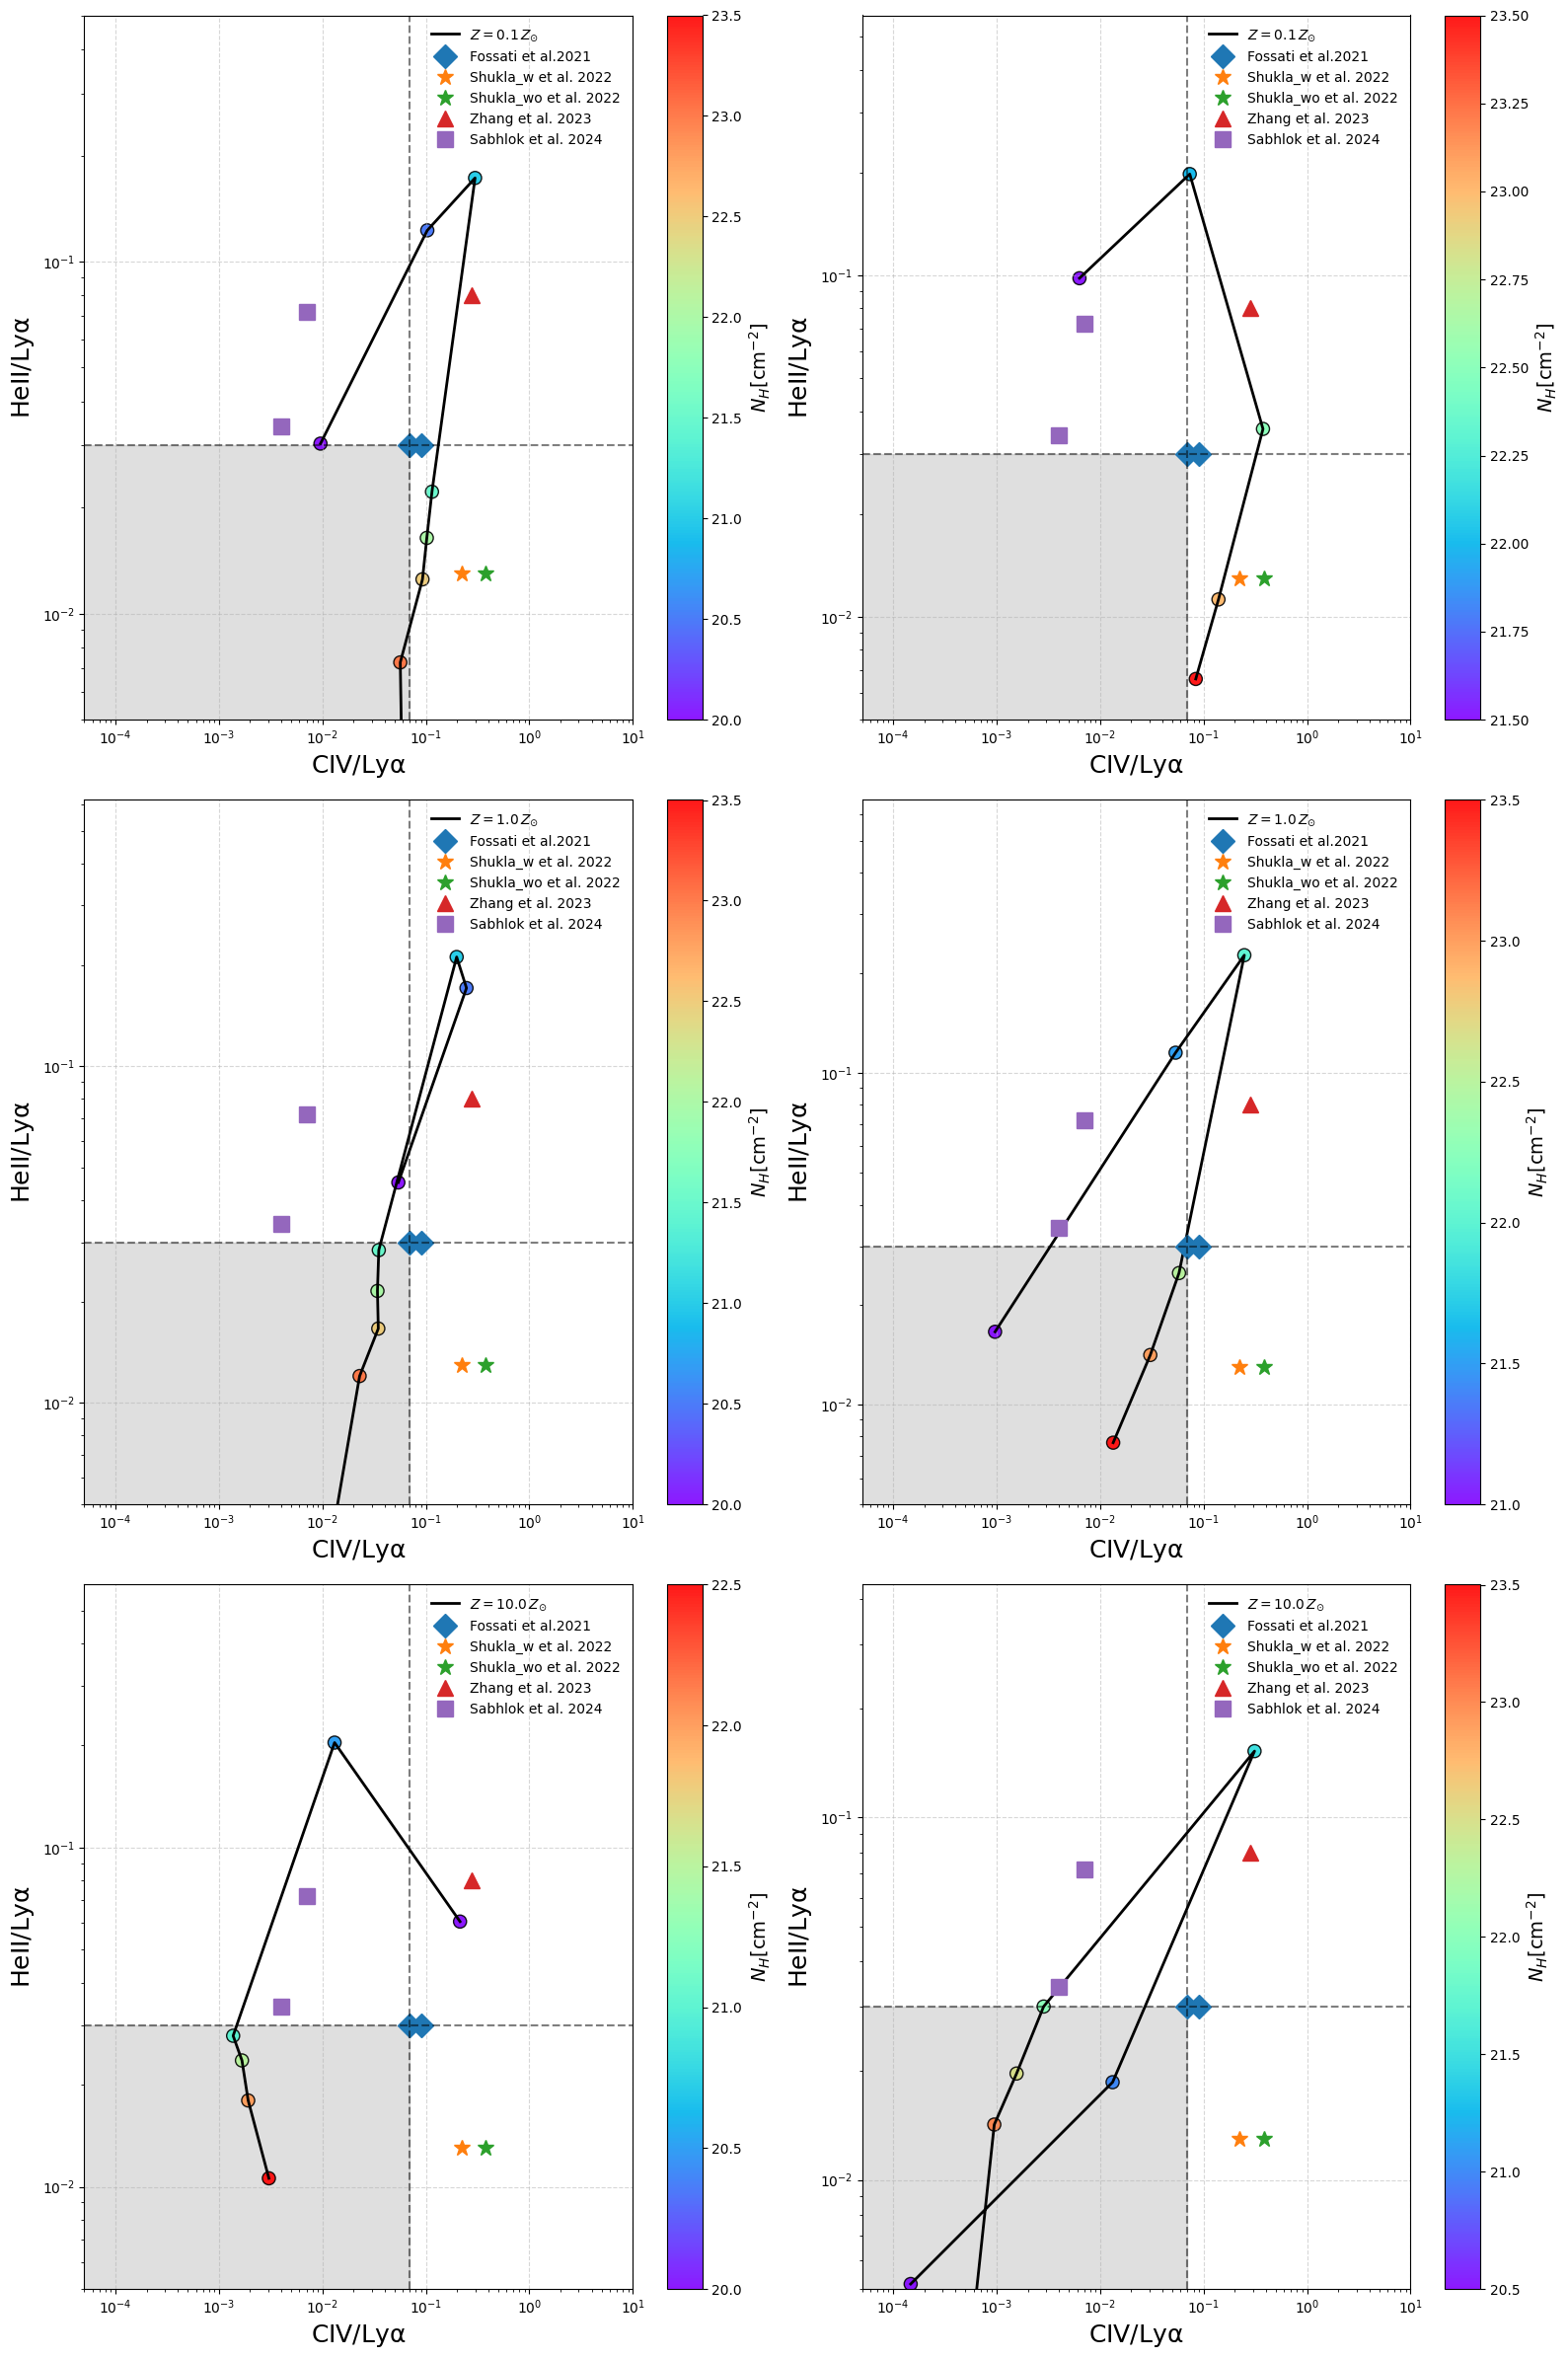

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ====== Matplotlib 속도/렌더링 최적화(무료) ======
plt.rcParams['path.simplify'] = True
plt.rcParams['agg.path.chunksize'] = 10000

# ====== 기본 파라미터 ======
N_list = np.arange(20.0, 24.0, 0.5)

# 1 kpc = 3.086e21 cm
kpc = 3.086e21
L_100kpc = 100 * kpc  # 100 kpc in cm

# Observational points
Hum_CIV = np.array([0.13,0.21,0.11,0.17,0.12,0.09,0.24])
Hum_HeII = np.array([0.17,0.12,0.08,0.06,0.07,0.06,0.20])

Fab_CIV = np.array([0.16,0.16,0.33,0.29,0.44,0.48,0.31,0.34,0.48,0.5,0.25,0.22,0.26])
Fab_HeII = np.array([0.11,0.11,0.27,0.22,0.38,0.39,0.24,0.26,0.41,0.41,0.23,0.18,0.22])

Fossat_CIV = np.array([0.07,0.09])
Fossat_HeII = np.array([0.03,0.03])

Zhang_CIV = np.array([0.28])
Zhang_HeII = np.array([0.08])

Sabhlokc_CIV = np.array([0.004,0.007])
Sabhlokc_HeII = np.array([0.034,0.072])

Shukla_CIV_w  = np.array([0.22])
Shukla_HeII_w  = np.array([0.066])

Shukla_CIV_wo  = np.array([0.38])
Shukla_HeII_wo  = np.array([0.013])


# ====== 공통 플로팅 함수: 중복 제거 + 코드 조금 더 빠르게 ======
def plot_panel(Lumin, Z, idx_2=2, add_legend=False):
    civ_vals = []
    heii_vals = []
    col_den_vals = []

    # CLOUDY 반복 호출 (여기가 가장 느린 부분이라 구조적으로는 어쩔 수 없음)
    for Column_density_order in N_list:
        cloudy_path = CLOUDY_path(Lumin, idx_2, Z, Column_density_order)
        cloudy_data = CLOUDY_data_path(cloudy_path)

        # Line luminosities
        L_civ  = cloudy_data['Lumin_CIV']
        L_heii = cloudy_data['Lumin_HeII']
        L_lya  = cloudy_data['Lumin_Lya']

        # Line ratios
        civ_vals.append(L_civ / L_lya)
        heii_vals.append(L_heii / L_lya)
        col_den_vals.append(Column_density_order)

    civ_vals = np.array(civ_vals)
    heii_vals = np.array(heii_vals)
    col_den_vals = np.array(col_den_vals)

    # ======= 필터링: x > 1e-4 조건 =======
    mask = civ_vals > 1e-4
    civ_vals = civ_vals[mask]
    heii_vals = heii_vals[mask]
    col_den_vals = col_den_vals[mask]

    # scatter (색 = column density)
    sc = plt.scatter(
        civ_vals, heii_vals,
        c=col_den_vals, cmap='rainbow',
        s=90, edgecolor='k', alpha=0.9
    )

    # metallicity track
    plt.plot(
        civ_vals, heii_vals,
        '-', lw=2, alpha=1.0, color='black',
        label=rf"$Z = {Z}\,Z_{{\odot}}$" if add_legend else None
    )

    # Colorbar
    cb = plt.colorbar(sc)
    cb.set_label(r'$N_H [{\rm cm^{-2}}]$', fontsize=14)

    # Axes 설정
    plt.xlabel(r'${\rm CIV} / {\rm Ly\alpha}$', fontsize=18)
    plt.ylabel(r'${\rm HeII} / {\rm Ly\alpha}$', fontsize=18)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlim(5e-5, 10)

    # 관측점
    plt.plot(Fossat_CIV, Fossat_HeII, 'D', markersize=12, label='Fossati et al.2021')
    plt.plot(Shukla_CIV_w, Shukla_HeII_wo, '*', markersize=12, label='Shukla_w et al. 2022')
    plt.plot(Shukla_CIV_wo, Shukla_HeII_wo, '*', markersize=12, label='Shukla_wo et al. 2022')
    plt.plot(Zhang_CIV, Zhang_HeII, '^', markersize=12, label='Zhang et al. 2023')
    plt.plot(Sabhlokc_CIV, Sabhlokc_HeII, 's', markersize=12, label='Sabhlok et al. 2024')

    # 점선 기준선
    plt.axvline(x=0.07, ymin=0, ymax=1, linestyle='--', color='k', alpha=0.5)
    plt.axhline(y=0.03, xmin=0, xmax=1, linestyle='--', color='k', alpha=0.5)

    # ======= 회색 음영: x<0.07 AND y<0.03 영역(좌하단 직사각형) =======
    # 로그축에서 0은 못 쓰니까 아주 작은 값 사용
    ax = plt.gca()
    ax.fill_between([1e-10, 0.07], 1e-10, 0.03, color='grey', alpha=0.25, zorder=0)

    # 기타
    if add_legend:
        plt.legend(frameon=False)
    plt.grid(True, ls='--', alpha=0.5)

    return sc


# ====== Figure ======
fig = plt.figure(1, figsize=(16, 24))

# (321) Z=0.1, L=43.5
plt.subplot(321)
plot_panel(Lumin=43.5, Z=0.1, idx_2=2, add_legend=True)
plt.ylim(ymin=5e-3)
plt.tight_layout()

# (322) Z=0.1, L=45.5
plt.subplot(322)
plot_panel(Lumin=45.5, Z=0.1, idx_2=2, add_legend=True)
plt.ylim(ymin=5e-3)
plt.tight_layout()

# (323) Z=1.0, L=43.5
plt.subplot(323)
plot_panel(Lumin=43.5, Z=1.0, idx_2=2, add_legend=True)
plt.ylim(ymin=5e-3)
plt.tight_layout()

# (324) Z=1.0, L=45.5
plt.subplot(324)
plot_panel(Lumin=45.5, Z=1.0, idx_2=2, add_legend=True)
plt.ylim(ymin=5e-3)
plt.tight_layout()

# (325) Z=10.0, L=43.5
plt.subplot(325)
plot_panel(Lumin=43.5, Z=10.0, idx_2=2, add_legend=True)
plt.ylim(ymin=5e-3)
plt.tight_layout()

# (326) Z=10.0, L=45.5
plt.subplot(326)
plot_panel(Lumin=45.5, Z=10.0, idx_2=2, add_legend=True)
plt.ylim(ymin=5e-3)
plt.tight_layout()

# plt.show()

plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Line_ratio.pdf', bbox_inches='tight')


Del Lambda = 15.5 Angstrom
ratio of Peak and Continuum = 5.75e+01
Continuum = 6.00e+40 erg/s/A
Peak = 3.51e+42 erg/s/A
velocity dispersion = 3.00e+03 km/s
lmabda_c = 1546.147079489674 A
Equivalent Width = 1577.32 Angstrom
Total Luminosity of QSO C IV = 9.46e+43 erg/s
Total Luminosity of Continuum at 1500-1600 A = 6.00e+42 erg/s


Text(0, 0.5, '$L_{\\lambda}~[\\rm erg \\, s^{-1} \\, \\AA^{-1}]$')

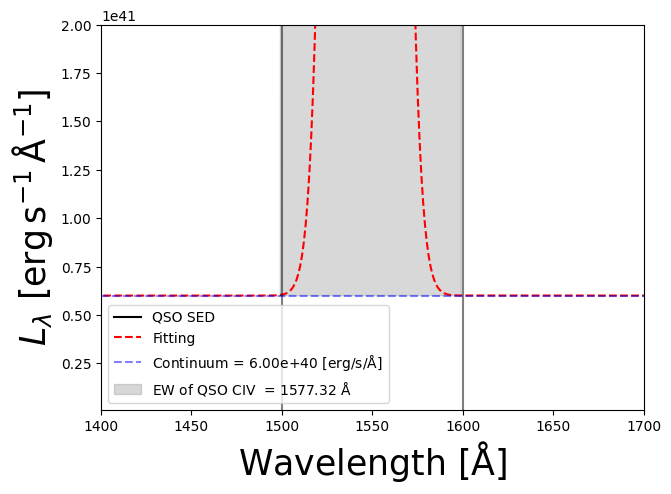

In [12]:

def Flux(Fc,F_max,lam,lam_c,sig_vel):
    del_lam = sig_vel / c_kms  * lam_c
    Flux = (F_max-Fc)*np.exp(- (lam-lam_c)**2 / (del_lam**2)) + Fc
    return Flux
def EW(Fc,F_max,lam_c,sig_vel):
    del_lam = sig_vel / c_kms  * lam_c
    print(f'Del Lambda = {del_lam*1e8:.1f} Angstrom')
    # print('dlam',del_lam)
    EW =abs((F_max - Fc)/ Fc)*np.sqrt(np.pi)*del_lam  # dimension of lambda
    print(f'ratio of Peak and Continuum = {abs((F_max - Fc)/ Fc):.2e}')
    return EW

def Ryd_to_lam(Ryd_x):
    lambda_x = c_cms /  (Ryd_x * 13.6 /h_ev) *1e8


Ryd, Fnu = QSO_SED(cloudy_path_2) # [1/Hz]
nu = (Ryd * 13.6 /h_ev) # 1/s = Hz
nuFnu = Fnu * nu # dimenionless parameter 

normalized_factor = 10**(Lumin)/nuFnu[np.where(Ryd==1)[0]] # erg/s


fig = plt.figure(1,figsize=(7,5))

# plt.subplot(121)
Lnu = Fnu*normalized_factor # erg/s/Hz
nuLnu = Fnu*normalized_factor*nu # erg/s

lambda_cm = c_cms /  (Ryd * 13.6 /h_ev) # cm
lambda_A =  c_cms /  (Ryd * 13.6 /h_ev)*1e8

ii = np.where((lambda_cm >1400e-8) & (lambda_cm <= 1700e-8))[0]

Llambda= Lnu* c_cms / (lambda_cm)**2 * 1e-8 # erg/s/cm *1e-8 -> erg/s/A




# Lc = 1.9e42  # erg/s/A
Lc = 6.0e40
aa = np.argmax(Llambda[ii])
Llambda_max = Llambda[ii[aa]] 
lambda_c = lambda_cm[ii[aa]]
# print(lambda_c)
# lambda_c =(C_IV_K + C_IV_H)/2
nu_c = c_cms / lambda_cm[ii[aa]] 
# print(Llambda_max )

sig_vel = 3000 #km/s
flux = Flux(Lc,Llambda_max,lambda_cm,lambda_c,sig_vel) # erg/s/A
ew = EW(Lc,Llambda_max,lambda_c,sig_vel)*1e8 # A

CIV_total_flux_QSO = ew*Lc #* nu_c
Lc_total_flux_QSO = Lc*   (1600-1500)  # erg/s #[min:max] of continuum


print(f'Continuum = {Lc:.2e} erg/s/A') 
print(f'Peak = {Llambda_max:.2e} erg/s/A') 
print(f'velocity dispersion = {sig_vel:.2e} km/s') 
print(f'lmabda_c = {lambda_c*1e8} A') 

print(f'Equivalent Width = {ew:.2f} Angstrom')
print(f'Total Luminosity of QSO C IV = {CIV_total_flux_QSO:.2e} erg/s') 
print(f'Total Luminosity of Continuum at 1500-1600 A = {Lc_total_flux_QSO:.2e} erg/s') 


plt.plot(lambda_A, Llambda,'k-',label='QSO SED')
plt.plot(lambda_A,flux,'r--',label='Fitting')
plt.axhline(y=Lc,xmin=0,xmax=1,color='b',linestyle='--',alpha=0.5,label=f'Continuum = {Lc:.2e} $\\rm [erg/s/\AA]$')

# Shade area between Lc and Llambda for 1500–1600 Å where Llambda ≥ Lc
m = (lambda_A >= 1500) & (lambda_A <= 1600) & (Llambda >= Lc)
plt.fill_between(lambda_A, Lc, Llambda, where=m, color='gray', alpha=0.3, interpolate=True, label=f'EW of QSO CIV  = {ew:.2f} $\\rm \AA$')

plt.axvline(x=1500,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.5)
plt.axvline(x=1600,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.5)

plt.xlim(1400,1700)
# plt.ylim(ymin=1e42,ymax=5e42)
plt.ylim(ymin=0.1e40,ymax=2e41)
plt.legend()

plt.xlabel(r'Wavelength $[ \rm \AA]$',fontsize=25)
plt.ylabel(r'$L_{\lambda}~[\rm erg \, s^{-1} \, \AA^{-1}]$',fontsize=25)


# Llambda_lim = (Llambda[ii] - Lc)
# print(Llambda_lim.sum())

# print((1+0.85)* Lc)

# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/QSO_SED', bbox_inches='tight')
# 


In [13]:
Lumin =43.5 # 37.0 - 44.0 + 41.5, 42.5, 43.5 and 44.5
idx_1 = 1 # 1 "" and  2 "no line transfer"
idx_2 = 2
metals = 0.1 # 0.001 - 10.0
Column_density_order = 22.0  # 18.0 - 25.0
cloudy_path_1 = CLOUDY_path(Lumin,idx_1,metals,Column_density_order)
cloudy_path_2 = CLOUDY_path(Lumin,idx_2,metals,Column_density_order)

print(cloudy_path_1)
cloudy_1 = f"/home/jin/RT/Test_CLOUDY/number_den/hden_1/Lum_{Lumin}_1/metal_{metals}/N_H_1.0_22.0/QSO_W"
cloudy_2 = f"/home/jin/RT/Test_CLOUDY/number_den/hden_1/Lum_{Lumin}_1/metal_{metals}/N_H_1.0_22.0/QSO_WO"
cloudy_data_1 = CLOUDY_data_path(cloudy_1)
cloudy_data_2 = CLOUDY_data_path(cloudy_2)

z = 0
red_shift_f = (1+z)**4
sr_to_arc = (180*3600 / np.pi)**2
fac = 1.0 #red_shift_f / sr_to_arc
fig= plt.figure(1,figsize=(12,8))
plt.subplot(1,2,1)


atom = 'HeII'
# plt.plot(cloudy_data_1[f'radius_{Lumin}'],cloudy_data_1[f'emis_{atom}_{Lumin}'],'r-',label=f'{atom} with LT')
# plt.plot(cloudy_data_2[f'radius_{Lumin}_{2}'],cloudy_data_2[f'emis_{atom}_{Lumin}'],'r--',label=f'{atom} without LT')
atom = 'CIV'
# plt.plot(cloudy_data_1[f'radius_{Lumin}'],cloudy_data_1[f'emis_{atom}_{Lumin}'],'b-',label=f'{atom} with LT')
plt.plot(cloudy_data_2[f'radius'],cloudy_data_2[f'emis_{atom}'],'k-',label=f'{atom} without LT')
# ax2.plot(cloudy_data_2[f'radius_{Lum}_{idx_2}'], cloudy_data_2[f'frac_CV_{Lum}_{idx_2}'],'r:',label = 'C V')
# ax2.plot(cloudy_data_2[f'radius_{Lum}_{idx_2}'], cloudy_data_2[f'frac_CIV_{Lum}_{idx_2}'],'g:',label = 'C IV')
# ax2.plot(cloudy_data_2[f'radius_{Lum}_{idx_2}'],cloudy_data_2[f'frac_CIII_{Lum}_{idx_2}'],'b:',label = 'C III')

plt.xlabel('Radius [kpc]')
plt.ylabel('Emissivity [erg/s/Hz/sr]')
plt.yscale('log')
plt.minorticks_on()
plt.grid(True,linestyle='--')

plt.legend()

plt.subplot(1,2,2)
# atom = 'HeII'
# plt.plot(cloudy_data_1[f'radius_{Lumin}'],cloudy_data_1[f'nden_{atom}_{Lumin}'],'r-',label=f'{atom} with LT')
# plt.plot(cloudy_data_2[f'radius_{Lumin}'],cloudy_data_2[f'nden_{atom}_{Lumin}'],'r--',label=f'{atom} without LT')
atom = 'CIV'
# plt.plot(cloudy_data_1[f'radius_{Lumin}'],cloudy_data_1[f'nden_{atom}_{Lumin}'],'b-',label=f'{atom} with LT')
plt.plot(cloudy_data_2[f'radius'],cloudy_data_2[f'nden_{atom}'],'k-',label=f'{atom} without LT')
plt.xlabel('Radius [kpc]')
plt.ylabel('Number Density [cm$^{-3}$]')
plt.yscale('log')

plt.minorticks_on()
plt.grid(True,linestyle='--')


plt.legend()


# print(f"HeI Luminosity = {cloudy_data_1[f'Lumin_HeI_{Lumin}_{idx}']:.4e} [erg/s]")

# f'Column_density_CIV_{Lumin}_{idx}'

# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/parameter', bbox_inches='tight')

/home/jin/CLOUDY_new_Data/Lum_43.5_1/metal_0.1/N_H_1.0_22.0/QSO_WO
warng CloudyModel /home/jin/RT/Test_CLOUDY/number_den/hden_1/Lum_43.5_1/metal_0.1/N_H_1.0_22.0/QSO_W/CIV_QSO: /home/jin/RT/Test_CLOUDY/number_den/hden_1/Lum_43.5_1/metal_0.1/N_H_1.0_22.0/QSO_W/CIV_QSO.out NOT read.


AttributeError: 'CloudyModel' object has no attribute 'ionic_names'

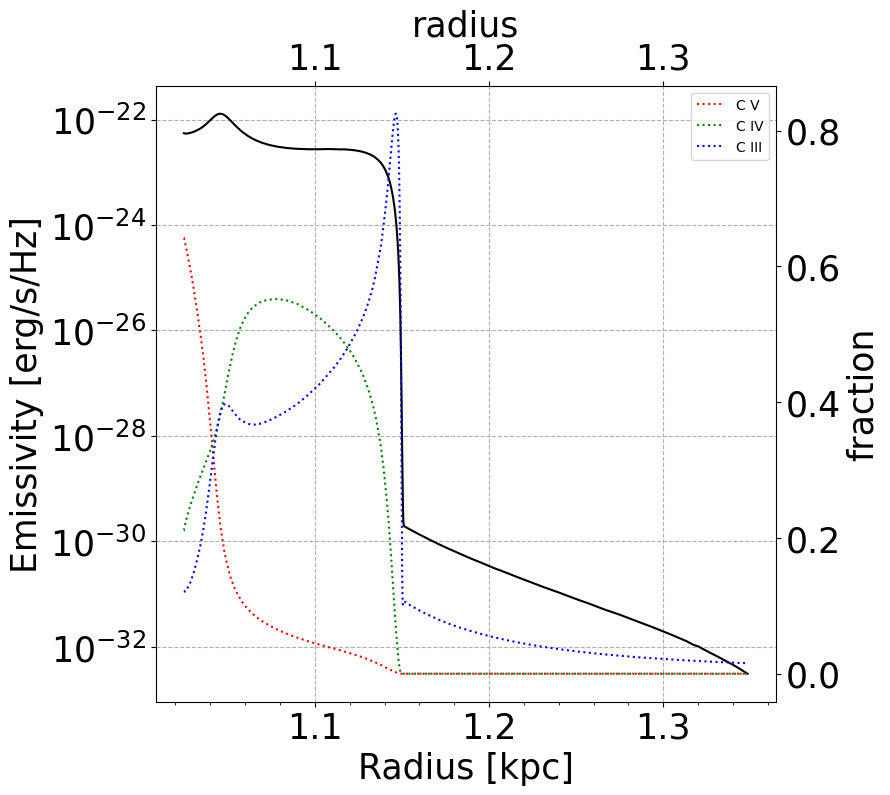

In [ ]:
fig= plt.figure(1,figsize=(8,8))

# fig = plt.figure(1, figsize=(8, 12))  # 세로로 조금 더 긴 그림
gs = gridspec.GridSpec(1, 1) 


ax1 = fig.add_subplot(gs[0])

atom = 'HeII'
# plt.plot(cloudy_data_1[f'radius_{Lumin}'],cloudy_data_1[f'emis_{atom}_{Lumin}'],'r-',label=f'{atom} with LT')
# plt.plot(cloudy_data_2[f'radius_{Lumin}_{2}'],cloudy_data_2[f'emis_{atom}_{Lumin}'],'r--',label=f'{atom} without LT')
atom = 'CIV'
# plt.plot(cloudy_data_1[f'radius_{Lumin}'],cloudy_data_1[f'emis_{atom}_{Lumin}'],'b-',label=f'{atom} with LT')
ax1.plot(cloudy_data_2[f'radius'],cloudy_data_2[f'emis_{atom}'],'k-',label=f'{atom} without LT')

ax2 = fig.add_axes(ax1.get_position(), frameon=False)

ax2.plot(cloudy_data_2[f'radius'], cloudy_data_2[f'frac_CV'],'r:',label = 'C V')
ax2.plot(cloudy_data_2[f'radius'], cloudy_data_2[f'frac_CIV'],'g:',label = 'C IV')
ax2.plot(cloudy_data_2[f'radius'],cloudy_data_2[f'frac_CIII'],'b:',label = 'C III')

ax1.set_xlabel('Radius [kpc]',fontsize=25)
ax1.set_ylabel('Emissivity [erg/s/Hz]',fontsize=25)
ax1.tick_params(axis='both', labelsize=25)
# ax2.set_ylabel('fraction',fontsize=25)
ax1.set_yscale('log')

ax1.minorticks_on()
ax1.grid(True,linestyle='--')


ax2.xaxis.set_ticks_position('top')
ax2.xaxis.set_label_position('top')
ax2.set_xlabel('radius', fontsize=25)

ax2.yaxis.set_ticks_position('right')
ax2.yaxis.set_label_position('right')
ax2.set_ylabel('fraction', fontsize=25)
ax2.tick_params(axis='both', labelsize=25)

plt.legend()


# ax3 = fig.add_subplot(gs[1])


# ax3.plot(radius_Te_WO_LT, SB_Te_WO_LT_HeII,'k-',lw=1,alpha=0.9,label='He II')
# ax3.plot(radius_Te_WO_LT,SB_Te_WO_LT,'k--',lw=1,alpha=0.9,label='C IV')

# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/parameter_fract', bbox_inches='tight')

In [ ]:
z_red_shift = 0 
atom = 'CIV'
red_shift_f = (1+z_red_shift)**4
# sr_to_arc = (180*3600 / np.pi)**2
fac = red_shift_f  #/ sr_to_arc

Lumin = 44.0
V_out = 100 
V_rand = 11.8
V_emit = 100
metals = 1.0
Column_density_order = 22.0

path_RT = "/home/jin/RT/Data_metal"
# style = 'radi'
geo = 'Nebula'
R_path = RT_CLOUDY_path(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,idx_2,metals,Column_density_order)
# a,b,c = RT_SB(R_path)
# print(a)

In [ ]:
Lumin = 44.0
V_out = 100 
V_rand = 11.8
path_RT = "/home/jin/RT/Data_metal"
style = 'radi'
V_out = 500 
geo = 2
V_emit = 100
metals = 1.0
path_test = RT_CLOUDY_path(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,idx_2,metals,Column_density_order)
# print(pp)
radius_Ne = RT_SB(path_test)[0]
Num_SB_Ne = RT_SB(path_test)[2]
# Num_SB_Ne
# number_dist_Ne, SB_Ne = photon_number_SB(radius_Ne,Num_SB_Ne ,cloudy_data_2[f'Lumin_{atom}']) 

Text(0, 0.5, '$\\rm SB(z) x (1+z)^4$ $\\rm [erg \\,s^{-1} \\, cm^{-2}]$ ')

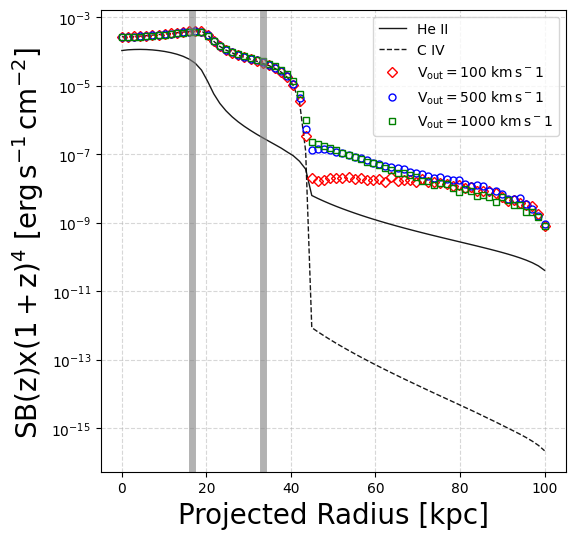

In [ ]:
fig = plt.figure(1,figsize=(6,6))

#Common 

z_red_shift = 0 
atom = 'CIV'
red_shift_f = (1+z_red_shift)**4
# sr_to_arc = (180*3600 / np.pi)**2
fac = red_shift_f  #/ sr_to_arc


path_RT = "/home/jin/RT/Data_metal"


Lumin = 44.0
V_out = 100 
V_rand = 11.8
metals = 0.1
Column_density_order = 22.0


cloudy_path_1 = CLOUDY_path(Lumin,idx_1,metals,Column_density_order)
cloudy_path_2 = CLOUDY_path(Lumin,idx_2,metals,Column_density_order)

cloudy_data_1 = CLOUDY_data_path(cloudy_path_1)
cloudy_data_2 = CLOUDY_data_path(cloudy_path_2)

#CLOUDY
geo= 'Test'
V_emit = 1.0
# path = RT_CLOUDY_path(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,idx_1,metals,Column_density_order)
# print(pp)
# radius_Te_W_LT = RT_SB(path)[0]
# Num_SB_Te_W_LT =RT_SB(path)[2]
# number_dist_W_LT, SB_Te_W_LT = photon_number_SB(radius_Te_W_LT,Num_SB_Te_W_LT,cloudy_data_1[f'Lumin_{atom}_{Lumin}']) 

# path = RT_CLOUDY_path(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,idx_2,metals,Column_density_order)
# radius_Te_WO_LT = RT_SB(path)[0]/
# Num_SB_Te_WO_LT = RT_SB(path)[2]
# number_dist_WO_LT, SB_Te_WO_LT = photon_number_SB(radius_Te_WO_LT,Num_SB_Te_WO_LT,cloudy_data_2[f'Lumin_{atom}_{Lumin}']) 

radius_Te_W_LT, SB_Te_W_LT = cloudy_data_1[f'radius_p'] , cloudy_data_1[f'SB_{atom}']
radius_Te_WO_LT, SB_Te_WO_LT = cloudy_data_2[f'radius_p'] , cloudy_data_2[f'SB_{atom}']

radius_Te_WO_LT, SB_Te_WO_LT_HeII = cloudy_data_2[f'radius_p'] , cloudy_data_2[f'SB_HeII']

#Nebula
geo = 'Nebula'
V_emit = 3000
path = RT_CLOUDY_path(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,idx_2,metals,Column_density_order)
radius_Ne =  RT_SB(path)[0]
Num_SB_Ne =  RT_SB(path)[2]
number_dist_Ne, SB_Ne = photon_number_SB(radius_Ne,Num_SB_Ne ,cloudy_data_2[f'Lumin_{atom}']) 

# plt.plot(radius_from_CLOUDY,SB_from_CLOUDY )
# plt.plot(radius_Te_W_LT,SB_Te_W_LT,'k--',label='CLOUDY_W_LT')
plt.plot(radius_Te_WO_LT, SB_Te_WO_LT_HeII,'k-',lw=1,alpha=0.9,label='He II')
plt.plot(radius_Te_WO_LT,SB_Te_WO_LT,'k--',lw=1,alpha=0.9,label='C IV')
plt.plot(radius_Ne,SB_Ne,marker='D',color='r',linestyle='', markersize=5, markerfacecolor='none', label=f'$\\rm V_{{\\rm out}} = {V_out}$ $\\rm km \,s^{-1}$') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$'




V_out = 500 
path = RT_CLOUDY_path(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,idx_2,metals,Column_density_order)
radius_Ne = RT_SB(path)[0]
Num_SB_Ne = RT_SB(path)[2]
number_dist_Ne, SB_Ne = photon_number_SB(radius_Ne,Num_SB_Ne ,cloudy_data_2[f'Lumin_{atom}']) 
plt.plot(radius_Ne,SB_Ne,marker='o',color='b',linestyle='', markersize=5, markerfacecolor='none', label=f'$\\rm V_{{\\rm out}} = {V_out}$ $\\rm km \,s^{-1}$') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$'


V_out = 1000 
path = RT_CLOUDY_path(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,idx_2,metals,Column_density_order)
radius_Ne = RT_SB(path)[0]
Num_SB_Ne = RT_SB(path)[2]
number_dist_Ne, SB_Ne = photon_number_SB(radius_Ne,Num_SB_Ne ,cloudy_data_2[f'Lumin_{atom}']) 
plt.plot(radius_Ne,SB_Ne,marker='s',color='g',linestyle='', markersize=5, markerfacecolor='none', label=f'$\\rm V_{{\\rm out}} = {V_out}$ $\\rm km \,s^{-1}$') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$'


# plt.plot(radius_Q,SB_Q,marker='o',color='b',linestyle='', markersize=5, markerfacecolor='none', label=f'QSO_Gaussian') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$

plt.axvline(x=33.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)
plt.axvline(x=16.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)

# plt.plot(radius_Ne,SB_Ne + SB_Q,marker='X',color='k',linestyle='', markersize=5, markerfacecolor='none', label=f'Nebula + QSO') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$'
# plt.plot(radius_Q,SB_Q,marker='o',color='b',linestyle='', markersize=5, markerfacecolor='none', label=f'QSO') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$

plt.yscale('log')

plt.legend()

plt.grid(True,linestyle='--',alpha=0.5)

plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2}]$ ', fontsize=20)
# plt.ylim(ymin=1e-10)
# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/L440_M_1_V', bbox_inches='tight')

Text(0, 0.5, '$\\rm SB(z) x (1+z)^4$ $\\rm [erg \\,s^{-1} \\, cm^{-2}]$ ')

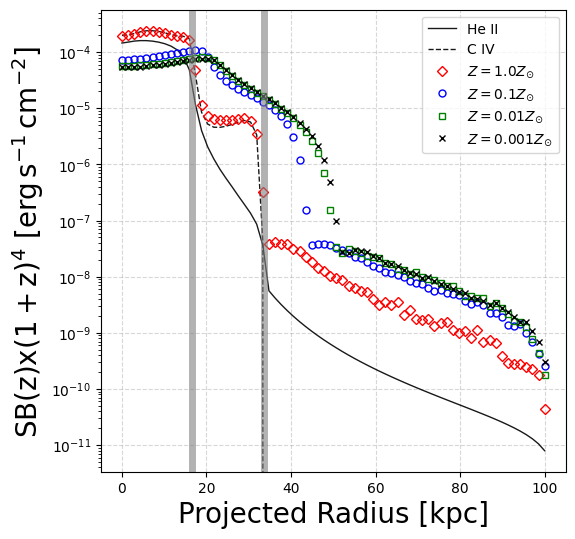

In [ ]:
fig = plt.figure(1,figsize=(6,6))

#Common 

z_red_shift = 0 
atom = 'CIV'
red_shift_f = (1+z_red_shift)**4
# sr_to_arc = (180*3600 / np.pi)**2
fac = red_shift_f  #/ sr_to_arc


path_RT = "/home/jin/RT/Data_metal"


Lumin = 44.0
V_out = 500 
V_rand = 11.8
metals = 1.0
Column_density_order = 22.0


cloudy_path_1 = CLOUDY_path(Lumin,idx_1,metals,Column_density_order)
cloudy_path_2 = CLOUDY_path(Lumin,idx_2,metals,Column_density_order)

cloudy_data_1 = CLOUDY_data_path(cloudy_path_1)
cloudy_data_2 = CLOUDY_data_path(cloudy_path_2)

#CLOUDY
geo= 'Test'
# V_emit = 1.0
radius_Te_W_LT, SB_Te_W_LT = cloudy_data_1[f'radius_p'] , cloudy_data_1[f'SB_{atom}']
radius_Te_WO_LT, SB_Te_WO_LT = cloudy_data_2[f'radius_p'] , cloudy_data_2[f'SB_{atom}']

radius_Te_WO_LT, SB_Te_WO_LT_HeII = cloudy_data_2[f'radius_p'] , cloudy_data_2[f'SB_HeII']

#Nebula
geo = 'Nebula'
V_emit = 3000
path = RT_CLOUDY_path(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,idx_2,metals,Column_density_order)
radius_Ne =  RT_SB(path)[0]
Num_SB_Ne =  RT_SB(path)[2]
number_dist_Ne, SB_Ne = photon_number_SB(radius_Ne,Num_SB_Ne ,cloudy_data_2[f'Lumin_{atom}']) 


# plt.plot(radius_from_CLOUDY,SB_from_CLOUDY )
# plt.plot(radius_Te_W_LT,SB_Te_W_LT,'k--',label='CLOUDY_W_LT')
plt.plot(radius_Te_WO_LT, SB_Te_WO_LT_HeII,'k-',lw=1,alpha=0.9,label='He II')
plt.plot(radius_Te_WO_LT,SB_Te_WO_LT,'k--',lw=1,alpha=0.9,label='C IV')



# metals = 1.0
plt.plot(radius_Ne,SB_Ne,marker='D',color='r',linestyle='', markersize=5, markerfacecolor='none',label=f'$ Z = {metals} Z_{{\\odot}} $ ') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$'



metals = 0.1
path = RT_CLOUDY_path(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,idx_2,metals,Column_density_order)
radius_Ne = RT_SB(path)[0]
Num_SB_Ne = RT_SB(path)[2]
number_dist_Ne, SB_Ne = photon_number_SB(radius_Ne,Num_SB_Ne ,cloudy_data_2[f'Lumin_{atom}']) 
plt.plot(radius_Ne,SB_Ne,marker='o',color='b',linestyle='', markersize=5, markerfacecolor='none', label=f'$ Z = {metals} Z_{{\\odot}} $ ') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$'

metals = 0.01
path = RT_CLOUDY_path(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,idx_2,metals,Column_density_order)
radius_Ne = RT_SB(path)[0]
Num_SB_Ne = RT_SB(path)[2]
number_dist_Ne, SB_Ne = photon_number_SB(radius_Ne,Num_SB_Ne ,cloudy_data_2[f'Lumin_{atom}']) 
plt.plot(radius_Ne,SB_Ne,marker='s',color='g',linestyle='', markersize=5, markerfacecolor='none', label=f'$ Z = {metals} Z_{{\\odot}} $ ') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$'


metals = 0.001
path = RT_CLOUDY_path(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,idx_2,metals,Column_density_order)
radius_Ne = RT_SB(path)[0]
Num_SB_Ne = RT_SB(path)[2]
number_dist_Ne, SB_Ne = photon_number_SB(radius_Ne,Num_SB_Ne ,cloudy_data_2[f'Lumin_{atom}']) 
plt.plot(radius_Ne,SB_Ne,marker='x',color='k',linestyle='', markersize=5, markerfacecolor='none', label=f'$ Z = {metals} Z_{{\\odot}} $ ') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$'


# metals = 10.0
# path = RT_CLOUDY_path(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,idx_2,metals,Column_density_order)
# radius_Ne = RT_SB(path)[0]
# Num_SB_Ne = RT_SB(path)[2]
# number_dist_Ne, SB_Ne = photon_number_SB(radius_Ne,Num_SB_Ne ,cloudy_data_2[f'Lumin_{atom}']) 
# plt.plot(radius_Ne,SB_Ne,marker='^',color='y',linestyle='', markersize=5, markerfacecolor='none',label=f'$ Z = {metals} Z_{{\\odot}} $ ') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$'




# plt.plot(radius_Q,SB_Q,marker='o',color='b',linestyle='', markersize=5, markerfacecolor='none', label=f'QSO_Gaussian') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$

plt.axvline(x=33.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)
plt.axvline(x=16.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)

# plt.plot(radius_Ne,SB_Ne + SB_Q,marker='X',color='k',linestyle='', markersize=5, markerfacecolor='none', label=f'Nebula + QSO') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$'
# plt.plot(radius_Q,SB_Q,marker='o',color='b',linestyle='', markersize=5, markerfacecolor='none', label=f'QSO') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$

plt.yscale('log')

plt.legend()

plt.grid(True,linestyle='--',alpha=0.5)

plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2}]$ ', fontsize=20)
# plt.ylim(ymin=1e-10)
# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/L440_V_500_M', bbox_inches='tight')

Text(0, 0.5, '$\\rm SB(z) x (1+z)^4$ $\\rm [erg \\,s^{-1} \\, cm^{-2}]$ ')

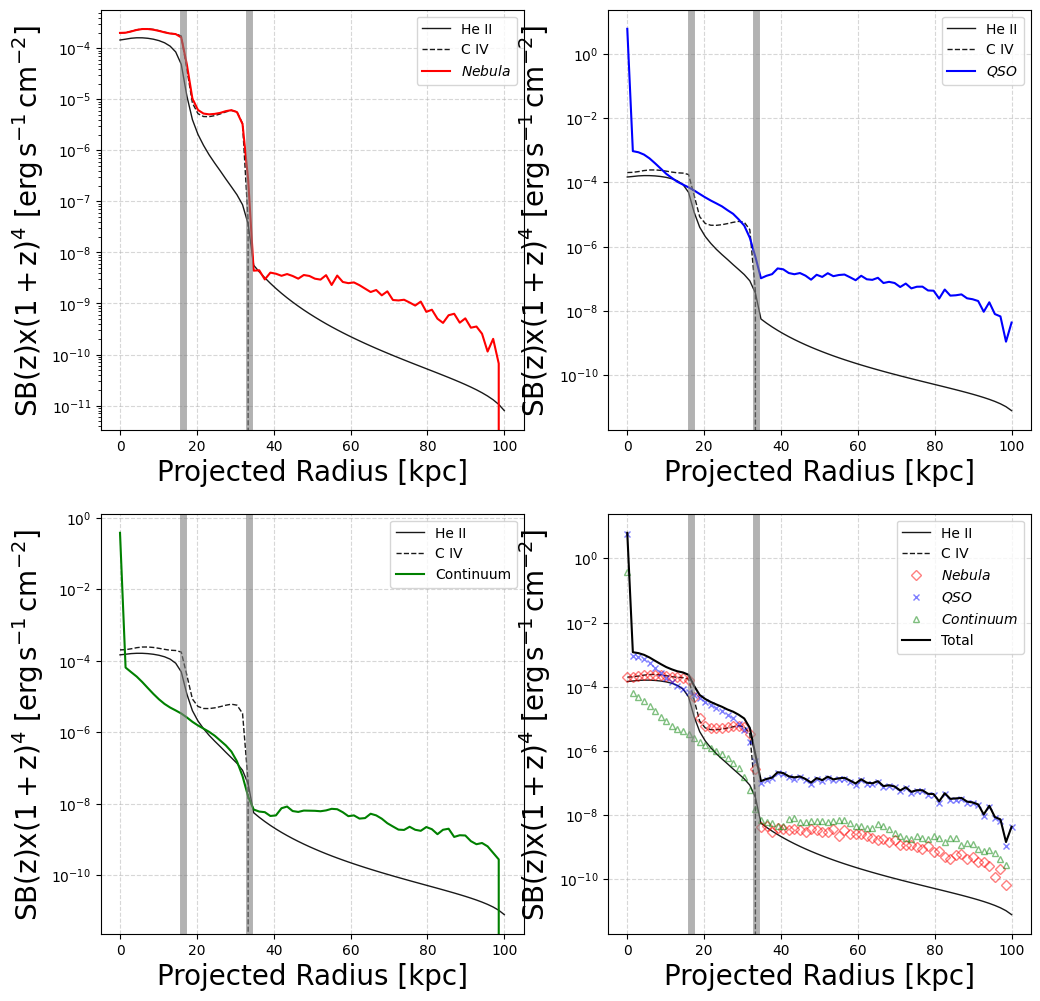

In [ ]:
fig = plt.figure(1,figsize=(12,12))

#Common 

z_red_shift = 0 
atom = 'CIV'
red_shift_f = (1+z_red_shift)**4
# sr_to_arc = (180*3600 / np.pi)**2
fac = red_shift_f  #/ sr_to_arc


path_RT = "/home/jin/RT/Data_metal"


Lumin = 44.0
V_out = 100 
V_rand = 11.8
metals = 1.0
Column_density_order = 22.0

cloudy_path_1 = CLOUDY_path(Lumin,idx_1,metals,Column_density_order)
cloudy_path_2 = CLOUDY_path(Lumin,idx_2,metals,Column_density_order)

cloudy_data_1 = CLOUDY_data_path(cloudy_path_1)
cloudy_data_2 = CLOUDY_data_path(cloudy_path_2)

#CLOUDY
geo= 'Test'
V_emit = 1.0
radius_Te_W_LT, SB_Te_W_LT = cloudy_data_1[f'radius_p'] , cloudy_data_1[f'SB_{atom}']
radius_Te_WO_LT, SB_Te_WO_LT = cloudy_data_2[f'radius_p'] , cloudy_data_2[f'SB_{atom}']

radius_Te_WO_LT, SB_Te_WO_LT_HeII = cloudy_data_2[f'radius_p'] , cloudy_data_2[f'SB_HeII']

# CIV_total_flux_QSO = ew*Lc #* nu_c
# Lc_total_flux_QSO = Lc*   (1600-1500)  
geo = 'Nebula'
V_emit = 3000
path = RT_CLOUDY_path(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,idx_2,metals,Column_density_order)
radius_Ne =  RT_SB(path)[0]
Num_SB_Ne =  RT_SB(path)[2]
number_dist_Ne, SB_Ne = photon_number_SB(radius_Ne,Num_SB_Ne ,cloudy_data_2[f'Lumin_{atom}']) 


geo = 'QSO'
path = RT_CLOUDY_path(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,idx_2,metals,Column_density_order)
radius_QSO =  RT_SB(path)[0]
Num_SB_QSO =  RT_SB(path)[2]
number_dist_QSO, SB_QSO = photon_number_SB(radius_QSO,Num_SB_QSO ,CIV_total_flux_QSO) 

geo = 'CONTINUUM'
path = RT_CLOUDY_path(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,idx_2,metals,Column_density_order)
radius_CONT =  RT_SB(path)[0]
Num_SB_CONT =  RT_SB(path)[2]
number_dist_CONT, SB_CONT = photon_number_SB(radius_CONT,Num_SB_CONT ,Lc_total_flux_QSO) 

plt.subplot(221)
#Nebula

plt.plot(radius_Te_WO_LT, SB_Te_WO_LT_HeII,'k-',lw=1,alpha=0.9,label='He II')
plt.plot(radius_Te_WO_LT,SB_Te_WO_LT,'k--',lw=1,alpha=0.9,label='C IV')
plt.plot(radius_Ne,SB_Ne,color='r',linestyle='-', markersize=5, markerfacecolor='none', label=f'$Nebula$') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$'
plt.axvline(x=33.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)
plt.axvline(x=16.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)

plt.yscale('log')

plt.legend()

plt.grid(True,linestyle='--',alpha=0.5)

plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2}]$ ', fontsize=20)


plt.subplot(222)
#QSO

plt.plot(radius_Te_WO_LT, SB_Te_WO_LT_HeII,'k-',lw=1,alpha=0.9,label='He II')
plt.plot(radius_Te_WO_LT,SB_Te_WO_LT,'k--',lw=1,alpha=0.9,label='C IV')
plt.plot(radius_QSO,SB_QSO,color='b',linestyle='-', markersize=5, markerfacecolor='none', label=f'$QSO$') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$'
plt.axvline(x=33.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)
plt.axvline(x=16.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)

plt.yscale('log')

plt.legend()

plt.grid(True,linestyle='--',alpha=0.5)

plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2}]$ ', fontsize=20)




plt.subplot(223)

plt.plot(radius_Te_WO_LT, SB_Te_WO_LT_HeII,'k-',lw=1,alpha=0.9,label='He II')
plt.plot(radius_Te_WO_LT,SB_Te_WO_LT,'k--',lw=1,alpha=0.9,label='C IV')
plt.plot(radius_CONT,SB_CONT,color='g',linestyle='-', markersize=5, markerfacecolor='none', label=f'Continuum') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$'
plt.axvline(x=33.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)
plt.axvline(x=16.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)

plt.yscale('log')

plt.legend()

plt.grid(True,linestyle='--',alpha=0.5)

plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2}]$ ', fontsize=20)



plt.subplot(224)

SB_total = SB_CONT + SB_QSO + SB_Ne



plt.plot(radius_Te_WO_LT, SB_Te_WO_LT_HeII,'k-',lw=1,alpha=0.9,label='He II')
plt.plot(radius_Te_WO_LT,SB_Te_WO_LT,'k--',lw=1,alpha=0.9,label='C IV')

plt.plot(radius_Ne,SB_Ne,marker='D',color='r',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5, label=f'$Nebula$')
plt.plot(radius_QSO,SB_QSO,marker='x',color='b',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5, label=f'$QSO$')
plt.plot(radius_QSO,SB_CONT,marker='^',color='g',linestyle='', markersize=5, markerfacecolor='none', alpha=0.5, label=f'$Continuum$')

plt.plot(radius_CONT,SB_total,color='k',linestyle='-', markersize=5, markerfacecolor='none', label=f'Total') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$'
plt.axvline(x=33.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)
plt.axvline(x=16.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)

plt.yscale('log')

plt.legend()

plt.grid(True,linestyle='--',alpha=0.5)

plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2}]$ ', fontsize=20)




3.511001002000279e+42
Del Lambda = 15.5 Angstrom
ratio of Peak and Continuum = 5.75e+01
Continuum = 1.60e-05 erg/s/A
Peak = 3.51e+42 erg/s/A
velocity dispersion = 3.00e+03 km/s
lmabda_c = 1546.147079489674 A
Equivalent Width = 1577.32 Angstrom
Total Luminosity of QSO C IV = 9.46e+43 erg/s
Total Luminosity of Continuum at 1500-1600 A = 6.00e+42 erg/s


Text(0, 0.5, '$L_{\\lambda}~[\\rm erg \\, s^{-1} \\, \\AA^{-1}]$')

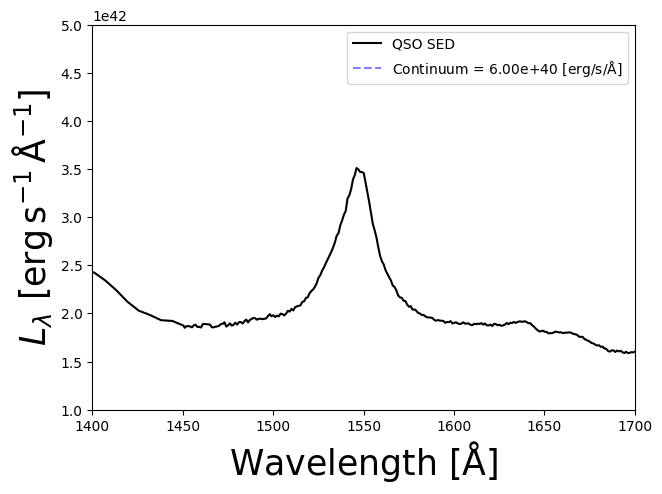

In [ ]:

Lumin = 45.5
V_out = 100 
V_rand = 11.8
metals = 0.1
Column_density_order = 22.0


cloudy_path_1 = CLOUDY_path(Lumin,idx_1,metals,Column_density_order)
cloudy_path_2 = CLOUDY_path(Lumin,idx_2,metals,Column_density_order)

cloudy_data_1 = CLOUDY_data_path(cloudy_path_1)
cloudy_data_2 = CLOUDY_data_path(cloudy_path_2)


def Flux(Fc,F_max,lam,lam_c,sig_vel):
    del_lam = sig_vel / c_kms  * lam_c
    Flux = (F_max-Fc)*np.exp(- (lam-lam_c)**2 / (del_lam**2)) + Fc
    return Flux
def EW(Fc,F_max,lam_c,sig_vel):
    del_lam = sig_vel / c_kms  * lam_c
    print(f'Del Lambda = {del_lam*1e8:.1f} Angstrom')
    # print('dlam',del_lam)
    EW =abs((F_max - Fc)/ Fc)*np.sqrt(np.pi)*del_lam  # dimension of lambda
    print(f'ratio of Peak and Continuum = {abs((F_max - Fc)/ Fc):.2e}')
    return EW

def find_fc(EW,F_max,lam_c,sig_vel):
    del_lam = sig_vel / c_kms  * lam_c
    a = EW/(np.sqrt(np.pi)*del_lam)
    Fc = F_max/(a+1)

    return Fc


def Ryd_to_lam(Ryd_x):
    lambda_x = c_cms /  (Ryd_x * 13.6 /h_ev) *1e8


Ryd, Fnu = QSO_SED(cloudy_path_2) # [1/Hz]
nu = (Ryd * 13.6 /h_ev) # 1/s = Hz
nuFnu = Fnu * nu # dimenionless parameter 

normalized_factor = 10**(Lumin)/nuFnu[np.where(Ryd==1)[0]] # erg/s


fig = plt.figure(1,figsize=(7,5))

# plt.subplot(121)
Lnu = Fnu*normalized_factor # erg/s/Hz
nuLnu = Fnu*normalized_factor*nu # erg/s

lambda_cm = c_cms /  (Ryd * 13.6 /h_ev) # cm
lambda_A =  c_cms /  (Ryd * 13.6 /h_ev)*1e8

ii = np.where((lambda_cm >1400e-8) & (lambda_cm <= 1700e-8))[0]

Llambda= Lnu* c_cms / (lambda_cm)**2 * 1e-8 # erg/s/cm *1e-8 -> erg/s/A



Lc = 6e40  # erg/s/A
sig_vel = 3000 #km/s

aa = np.argmax(Llambda[ii])
Llambda_max = Llambda[ii[aa]] 
lambda_c = lambda_cm[ii[aa]]

Lc_455 = find_fc(Lc, Llambda_max,lambda_c,sig_vel) 
print(Llambda_max)
# print(lambda_c)
# lambda_c =(C_IV_K + C_IV_H)/2
nu_c = c_cms / lambda_cm[ii[aa]] 
# print(Llambda_max )

flux = Flux(Lc,Llambda_max,lambda_cm,lambda_c,sig_vel) # erg/s/A
ew = EW(Lc,Llambda_max,lambda_c,sig_vel)*1e8 # A

CIV_total_flux_QSO_455 = ew*Lc #* nu_c
Lc_total_flux_QSO_455 = Lc*   (1600-1500)  # erg/s #[min:max] of continuum


print(f'Continuum = {Lc_455:.2e} erg/s/A') 
print(f'Peak = {Llambda_max:.2e} erg/s/A') 
print(f'velocity dispersion = {sig_vel:.2e} km/s') 
print(f'lmabda_c = {lambda_c*1e8} A') 

print(f'Equivalent Width = {ew:.2f} Angstrom')
print(f'Total Luminosity of QSO C IV = {CIV_total_flux_QSO_455:.2e} erg/s') 
print(f'Total Luminosity of Continuum at 1500-1600 A = {Lc_total_flux_QSO_455:.2e} erg/s') 


plt.plot(lambda_A, Llambda,'k-',label='QSO SED')
# plt.plot(lambda_A,flux,'r--',label='Fitting')
plt.axhline(y=Lc,xmin=0,xmax=1,color='b',linestyle='--',alpha=0.5,label=f'Continuum = {Lc:.2e} $\\rm [erg/s/\AA]$')

# # Shade area between Lc and Llambda for 1500–1600 Å where Llambda ≥ Lc
# m = (lambda_A >= 1500) & (lambda_A <= 1600) & (Llambda >= Lc)
# plt.fill_between(lambda_A, Lc, Llambda, where=m, color='gray', alpha=0.3, interpolate=True, label=f'EW of QSO CIV  = {ew:.2f} $\\rm \AA$')

# plt.axvline(x=1500,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.5)
# plt.axvline(x=1600,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.5)

plt.xlim(1400,1700)
# plt.yscale('log')
plt.ylim(ymin=1e42,ymax=5e42)

plt.legend()

plt.xlabel(r'Wavelength $[ \rm \AA]$',fontsize=25)
plt.ylabel(r'$L_{\lambda}~[\rm erg \, s^{-1} \, \AA^{-1}]$',fontsize=25)


# Llambda_lim = (Llambda[ii] - Lc)
# print(Llambda_lim.sum())

# print((1+0.85)* Lc)

# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/QSO_SED', bbox_inches='tight')
# 


Del Lambda = 15.5 Angstrom
ratio of Peak and Continuum = 8.50e-01
Lambda, Escape+Scattering Photon Spectrum, Scattering Photon Spectrum 
Lambda, Escape+Scattering Photon Spectrum, Scattering Photon Spectrum 
Lambda, Escape+Scattering Photon Spectrum, Scattering Photon Spectrum 
Total Gaussian of QSO luminosity = 1.40e+42 [erg/s]
Totla Flat of QSO luminosity  = 5.00e+41 [erg/s]
0.6153846153846154


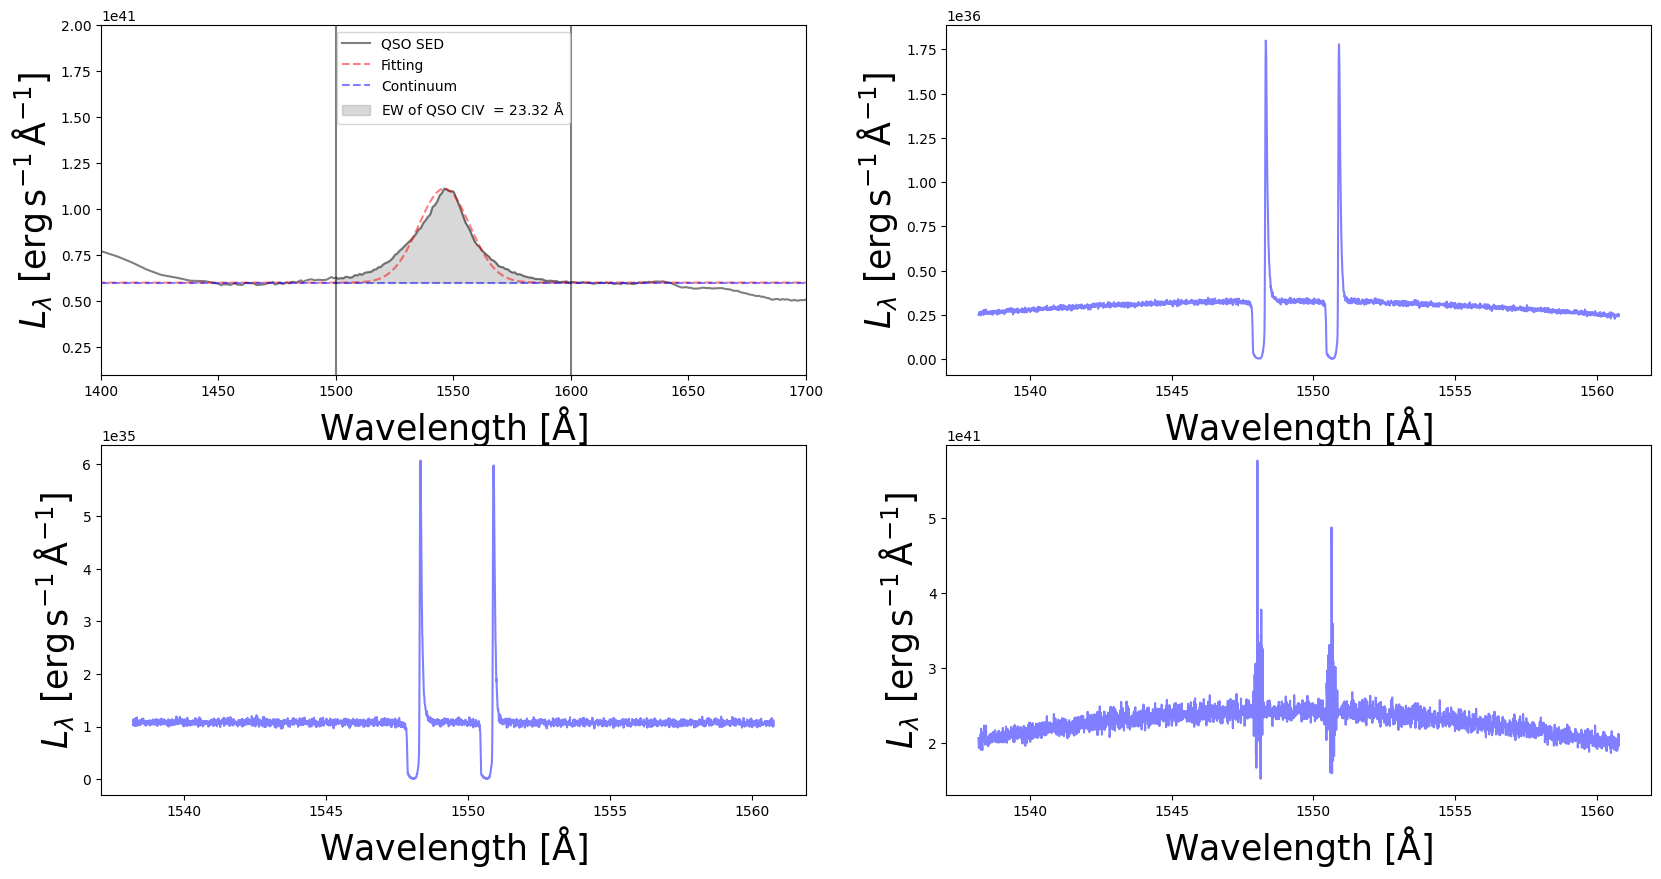

In [ ]:
from DATA_CHECK import *

fig = plt.figure(1,figsize=(20,10))

# path_d = '/home/jin/data_CIV'


# ----- Common -----
V_out  = 100
V_emit = 3000
V_rand = 11.8
# ----- Common -----

# ----- Data -----
# atom_num, atom_index = 32 , 15
# path_Data = Data_path(path_d,style, atom_num, atom_index , V_out, V_emit, V_rand)
# print(path_Data)
# ----- Data -----



#------ SB --------

atom = 'CIV'
# path_s = '/home/jin/RT/Data_RT/data'
path_s = "/home/jin/RT/Data_metal"
data_file = 'no'
Lumin = 44.0 
idx = 2
metals = 1.0
Column_density_order = 22.0


V_out  = 100
V_emit = 3000
V_rand = 11.8

path_sed =  CLOUDY_path(Lumin,2,metals,Column_density_order)
Ryd, Fnu = QSO_SED(path_sed) # [1/Hz]
nu = (Ryd * 13.6 /h_ev) # 1/s = Hz
nuFnu = Fnu * nu # dimenionless parameter 

normalized_factor = 10**(Lumin)/nuFnu[np.where(Ryd==1)[0]] # erg/s
Lnu = Fnu*normalized_factor # erg/s/Hz
nuLnu = Fnu*normalized_factor*nu # erg/s

lambda_cm = c_cms /  (Ryd * 13.6 /h_ev) # cm
lambda_A =  c_cms /  (Ryd * 13.6 /h_ev)*1e8

ii = np.where((lambda_cm >1400e-8) & (lambda_cm <= 1700e-8))[0]

Llambda= Lnu* c_cms / (lambda_cm)**2 * 1e-8 # erg/s/cm *1e-8 -> erg/s/A


Lc = 6e40  # erg/s/A
aa = np.argmax(Llambda[ii])
Llambda_max = Llambda[ii[aa]] 
lambda_c = lambda_cm[ii[aa]]
# print(lambda_c)
# lambda_c =(C_IV_K + C_IV_H)/2
nu_c = c_cms / lambda_cm[ii[aa]] 
# print(Llambda_max )

sig_vel = 3000 #km/s
flux = Flux(Lc,Llambda_max,lambda_cm,lambda_c,sig_vel) # erg/s/A
ew = EW(Lc,Llambda_max,lambda_c,sig_vel)*1e8 # A

Geometry = 4
path_cont =RT_CLOUDY_path(path_s,V_out, V_emit, V_rand, Geometry, atom, Lumin,idx,metals,Column_density_order)
lam_cont, spec_tot_cont, spec_sc_cont = spec_com(path_cont)

lam_min = lam_cont.min()
lam_max = lam_cont.max()

plt.subplot(221)

plt.plot(lambda_A, Llambda,'k-',label='QSO SED',alpha=0.5)
plt.plot(lambda_A,flux,'r--',label='Fitting',alpha=0.5)
plt.axhline(y=Lc,xmin=0,xmax=1,color='b',linestyle='--',alpha=0.5,label='Continuum')

m = (lambda_A >= 1500) & (lambda_A <= 1600) & (Llambda >= Lc)
plt.fill_between(lambda_A, Lc, Llambda, where=m, color='gray', alpha=0.3, interpolate=True, label=f'EW of QSO CIV  = {ew:.2f} $\\rm \AA$')



# 
jj = np.where((lambda_A >= lam_min)& (lambda_A <= lam_max) )
# print(jj)
# plt.plot(lambda_A[jj], Llambda[jj],'b--',label='QSO SED')
# Llambda_lim = (Llambda[jj] - Lc)
# print(Llambda_lim.sum())

# plt.axvline(x=lam_min,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.5)
# plt.axvline(x=lam_max,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.5)

# print((Llambda[jj]-flux[jj]).sum())

plt.axvline(x=1500,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.5)
plt.axvline(x=1600,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.5)

plt.xlim(1400,1700)
plt.ylim(ymin=0.1e41,ymax=2e41)

plt.legend()

plt.xlabel(r'Wavelength $[ \rm \AA]$',fontsize=25)
plt.ylabel(r'$L_{\lambda}~[\rm erg \, s^{-1} \, \AA^{-1}]$',fontsize=25)



plt.subplot(222)
Geometry = 3  # 1 = Test , 2 = Nebula , 3 = QSO, 4 = AGN_con, 5 = Flat
path_qso =RT_CLOUDY_path(path_s,V_out, V_emit, V_rand, Geometry, atom, Lumin,idx,metals,Column_density_order)

lam_qso, spec_tot_qso, spec_sc_qso = spec_com(path_qso)
# plt.plot(lam_cont,spec_tot_cont,'b-',alpha=0.5)


C_IV_total_Gaussian = Lc * ew
factor = C_IV_total_Gaussian / np.sum(spec_tot_qso)
test_qso = spec_tot_qso * factor  / lam_qso  #[erg/s/A]


plt.plot(lam_qso,test_qso,'b-',alpha=0.5)

plt.xlabel(r'Wavelength $[ \rm \AA]$',fontsize=25)
plt.ylabel(r'$L_{\lambda}~[\rm erg \, s^{-1} \, \AA^{-1}]$',fontsize=25)


plt.subplot(223)
Geometry = 4 # 1 = Test , 2 = Nebula , 3 = QSO, 4 = AGN_con, 5 = Flat
path_cont =RT_CLOUDY_path(path_s,V_out, V_emit, V_rand, Geometry, atom, Lumin,idx,metals,Column_density_order)

lam_cont, spec_tot_cont, spec_sc_cont = spec_com(path_cont)
# plt.plot(lam_cont,spec_tot_cont,'b-',alpha=0.5)

# C_IV_total_Flat =  Lc * (1600-1500)  #(lam_cont.max()-lam_cont.min()) 
C_IV_total_Flat = 0.5e42
factor = C_IV_total_Flat   / np.sum(spec_tot_cont)
test_cont = spec_tot_cont * factor / lam_cont  #[erg/s/A]

plt.plot(lam_cont,test_cont,'b-',alpha=0.5)
plt.xlabel(r'Wavelength $[ \rm \AA]$',fontsize=25)
plt.ylabel(r'$L_{\lambda}~[\rm erg \, s^{-1} \, \AA^{-1}]$',fontsize=25)



plt.subplot(224)

# y = spec_tot_cont + spec_tot_qso

ff = (test_cont+test_qso) / test_cont
y= ff*Lc
plt.plot(lam_cont,y,'b-',alpha=0.5)

# print(f'Total_Lum = {y.sum():.2e}')
print(f'Total Gaussian of QSO luminosity = {C_IV_total_Gaussian:.2e} [erg/s]')
print(f'Totla Flat of QSO luminosity  = {C_IV_total_Flat:.2e} [erg/s]')
plt.xlabel(r'Wavelength $[ \rm \AA]$',fontsize=25)
plt.ylabel(r'$L_{\lambda}~[\rm erg \, s^{-1} \, \AA^{-1}]$',fontsize=25)

# print(Llambda_max)



# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/paramete', bbox_inches='tight')

print((2.1-1.3)/1.3)

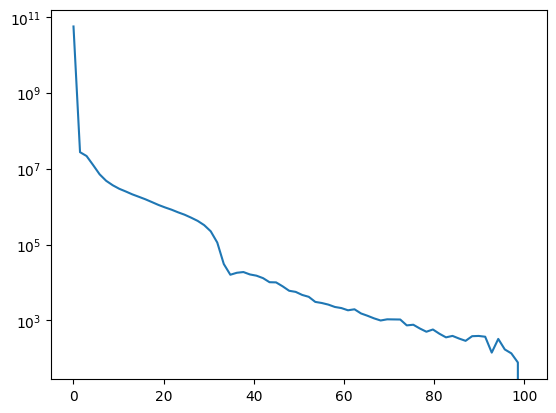

In [ ]:
from DATA_CHECK import *

Geometry = 3  # 1 = Test , 2 = Nebula , 3 = QSO, 4 = AGN_con, 5 = Flat
atom = 'CIV'
path_s = '/home/jin/RT/RT_scat'
data_file = 'CLOUDY'
Lumin = 44.0 
idx = 2
metals = 1.0
Column_density_order = 22.0

V_out  = 500 
V_emit = 3000
V_rand = 11.8

path_SB =RT_CLOUDY_path(path_s,V_out, V_emit, V_rand, Geometry, atom, Lumin,idx,metals,Column_density_order)
radius_CIV, SB_CIV = RT_SB(path_SB)[0], RT_SB(path_SB)[2]

plt.plot(radius_CIV,SB_CIV)
plt.yscale('log')
